In [1]:
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directories to path
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'parameters'))
sys.path.insert(0, os.getcwd())

from analysis_utils import (
    load_best_runs,
    load_top_n_runs,
    load_all_runs,
    extract_history,
    add_wall_times,
    build_summary_dataframe,
    plot_convergence_heatmap,
    plot_efficiency_scatter,
    plot_ranking_bar,
    plot_convergence_curves,
    plot_multi_function_performance,
    plot_hp_sensitivity,
    print_convergence_summary,
    print_best_hyperparameters,
    save_best_hyperparameters,
    print_ranking_table,
    print_variant_comparison,
    print_variant_comparison_allruns,
    print_hp_sensitivity_table,
    print_offdiag_ranking,
    get_optimizer_colors,
    ALL_OPTIMIZERS,
    # Budget-aware statistical methods
    bootstrap_best_run_ci,
    print_topk_comparison,
    print_robustness_table,
    plot_best_of_budget,
)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

from analysis_utils import (
    plot_diagnostic_curves,
    plot_effective_lr_comparison,
    DIAG_KEYS_METRIC_SCALE,
    DIAG_KEYS_LEARNABLE,
    DIAG_KEYS_CURVATURE,
    DIAG_KEYS_TRAINING,
    DIAG_KEYS_OFFDIAG,
)

# Configuration


In [2]:
# Backend: "wandb" or "local"
BACKEND = "local"

# WandB settings (ignored if BACKEND == "local")
PROJECT = "induced_metric"
ENTITY = "thomas_harvey"

# Results directory (for local backend)
RESULTS_DIR = os.path.join('..', '..', 'results')

# Test functions to analyse
FUNCTIONS = ['beale', 'rosenbrock', 'himmelblau', 'ackley', 'rastrigin', 'styblinski_tang']

# Iteration/batch number to load results from
ITERATION = 4

# Auto-detect which optimizers have results for at least one function
if BACKEND == "local":
    _available = set()
    for func_name in FUNCTIONS:
        task_dir = os.path.join(RESULTS_DIR, f"small_examples_{func_name}")
        if os.path.isdir(task_dir):
            for opt in os.listdir(task_dir):
                if os.path.isdir(os.path.join(task_dir, opt, f"itr_{ITERATION}")):
                    _available.add(opt)
    # Keep the canonical ordering from ALL_OPTIMIZERS
    OPTIMIZERS = [o for o in ALL_OPTIMIZERS if o in _available]
else:
    OPTIMIZERS = ALL_OPTIMIZERS

colors = get_optimizer_colors(OPTIMIZERS)
print(f"Backend: {BACKEND}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Functions: {FUNCTIONS}")
print(f"Iteration: {ITERATION}")
print(f"Optimizers ({len(OPTIMIZERS)}): {OPTIMIZERS}")


Backend: local
Results dir: ../../results
Functions: ['beale', 'rosenbrock', 'himmelblau', 'ackley', 'rastrigin', 'styblinski_tang']
Iteration: 4
Optimizers (5): ['adam', 'sgd', 'sgd_learn_diag', 'sgd_learn_diag_curv', 'sgd_newton_diag']


# Load Results


In [3]:
# Load best runs for each function
all_best_runs = {}
for func_name in FUNCTIONS:
    task_tag = f"small_examples_{func_name}"
    print(f"\n--- {func_name.upper()} ---")

    best_runs = load_best_runs(
        backend=BACKEND,
        optimizers=OPTIMIZERS,
        task_tag=task_tag,
        project=PROJECT,
        entity=ENTITY,
        results_dir=RESULTS_DIR,
        metric_key="sweep_metric",
        direction="minimize",
        sort_metric="sweep_metric",
        sort_order="+",
        iteration=ITERATION,
    )
    all_best_runs[func_name] = best_runs

print(f"\nLoaded results for {len(all_best_runs)} functions")
for func_name, runs in all_best_runs.items():
    print(f"  {func_name}: {len(runs)} optimizers")


--- BEALE ---
Finding best run for adam...
  adam: run_320
Finding best run for sgd...


  sgd: run_374
Finding best run for sgd_learn_diag...
  sgd_learn_diag: No runs found
Finding best run for sgd_learn_diag_curv...
  sgd_learn_diag_curv: run_638
Finding best run for sgd_newton_diag...


  sgd_newton_diag: run_0

--- ROSENBROCK ---
Finding best run for adam...
  adam: run_322
Finding best run for sgd...


  sgd: run_0
Finding best run for sgd_learn_diag...
  sgd_learn_diag: run_22
Finding best run for sgd_learn_diag_curv...


  sgd_learn_diag_curv: run_427
Finding best run for sgd_newton_diag...
  sgd_newton_diag: run_0

--- HIMMELBLAU ---
Finding best run for adam...


...

  adam: run_349
Finding best run for sgd...
  sgd: run_0
Finding best run for sgd_learn_diag...
  sgd_learn_diag: No runs found
Finding best run for sgd_learn_diag_curv...


  sgd_learn_diag_curv: run_926
Finding best run for sgd_newton_diag...
  sgd_newton_diag: run_309

--- STYBLINSKI_TANG ---
Finding best run for adam...


  adam: run_836
Finding best run for sgd...


  sgd: run_0
Finding best run for sgd_learn_diag...
  sgd_learn_diag: No runs found
Finding best run for sgd_learn_diag_curv...
  sgd_learn_diag_curv: run_145
Finding best run for sgd_newton_diag...


  sgd_newton_diag: run_30

Loaded results for 6 functions
  beale: 4 optimizers
  rosenbrock: 5 optimizers
  himmelblau: 4 optimizers
  ackley: 4 optimizers
  rastrigin: 4 optimizers
  styblinski_tang: 4 optimizers


In [4]:
# Extract history data for all functions
all_history_data = {}
for func_name in FUNCTIONS:
    best_runs = all_best_runs[func_name]
    if not best_runs:
        continue
    history_data = extract_history(
        BACKEND, best_runs, ["function_value", "runtime_seconds"]
    )
    add_wall_times(history_data, time_key="runtime_seconds")
    all_history_data[func_name] = history_data

# Build summary dataframe
summary_df = build_summary_dataframe(all_best_runs, optimizers=OPTIMIZERS)

print(f"Extracted history for {len(all_history_data)} functions")
print(f"Summary dataframe: {len(summary_df)} rows")

Processing adam...
Processing sgd...
Processing sgd_learn_diag_curv...
Processing sgd_newton_diag...
Processing adam...
Processing sgd...
Processing sgd_learn_diag...
Processing sgd_learn_diag_curv...
Processing sgd_newton_diag...
Processing adam...
Processing sgd...
Processing sgd_learn_diag_curv...
Processing sgd_newton_diag...
Processing adam...
Processing sgd...
Processing sgd_learn_diag_curv...
Processing sgd_newton_diag...
Processing adam...
Processing sgd...
Processing sgd_learn_diag_curv...
Processing sgd_newton_diag...
Processing adam...
Processing sgd...
Processing sgd_learn_diag_curv...
Processing sgd_newton_diag...
Extracted history for 6 functions
Summary dataframe: 25 rows


# Performance Comparison


In [5]:
if len(summary_df) == 0:
    print("No results found. Check RESULTS_DIR and ITERATION settings.")
else:
    print(f"Total results: {len(summary_df)}")
    print(f"Convergence rate: {summary_df['converged'].mean():.1%}")

    print("\nConvergence by optimizer:")
    conv = summary_df.groupby('optimizer')['converged'].agg(['count', 'sum', 'mean'])
    conv.columns = ['runs', 'converged', 'rate']
    print(conv.to_string())

Total results: 25
Convergence rate: 68.0%

Convergence by optimizer:
                     runs  converged      rate
optimizer                                     
adam                    6          5  0.833333
sgd                     6          3  0.500000
sgd_learn_diag          1          0  0.000000
sgd_learn_diag_curv     6          6  1.000000
sgd_newton_diag         6          3  0.500000


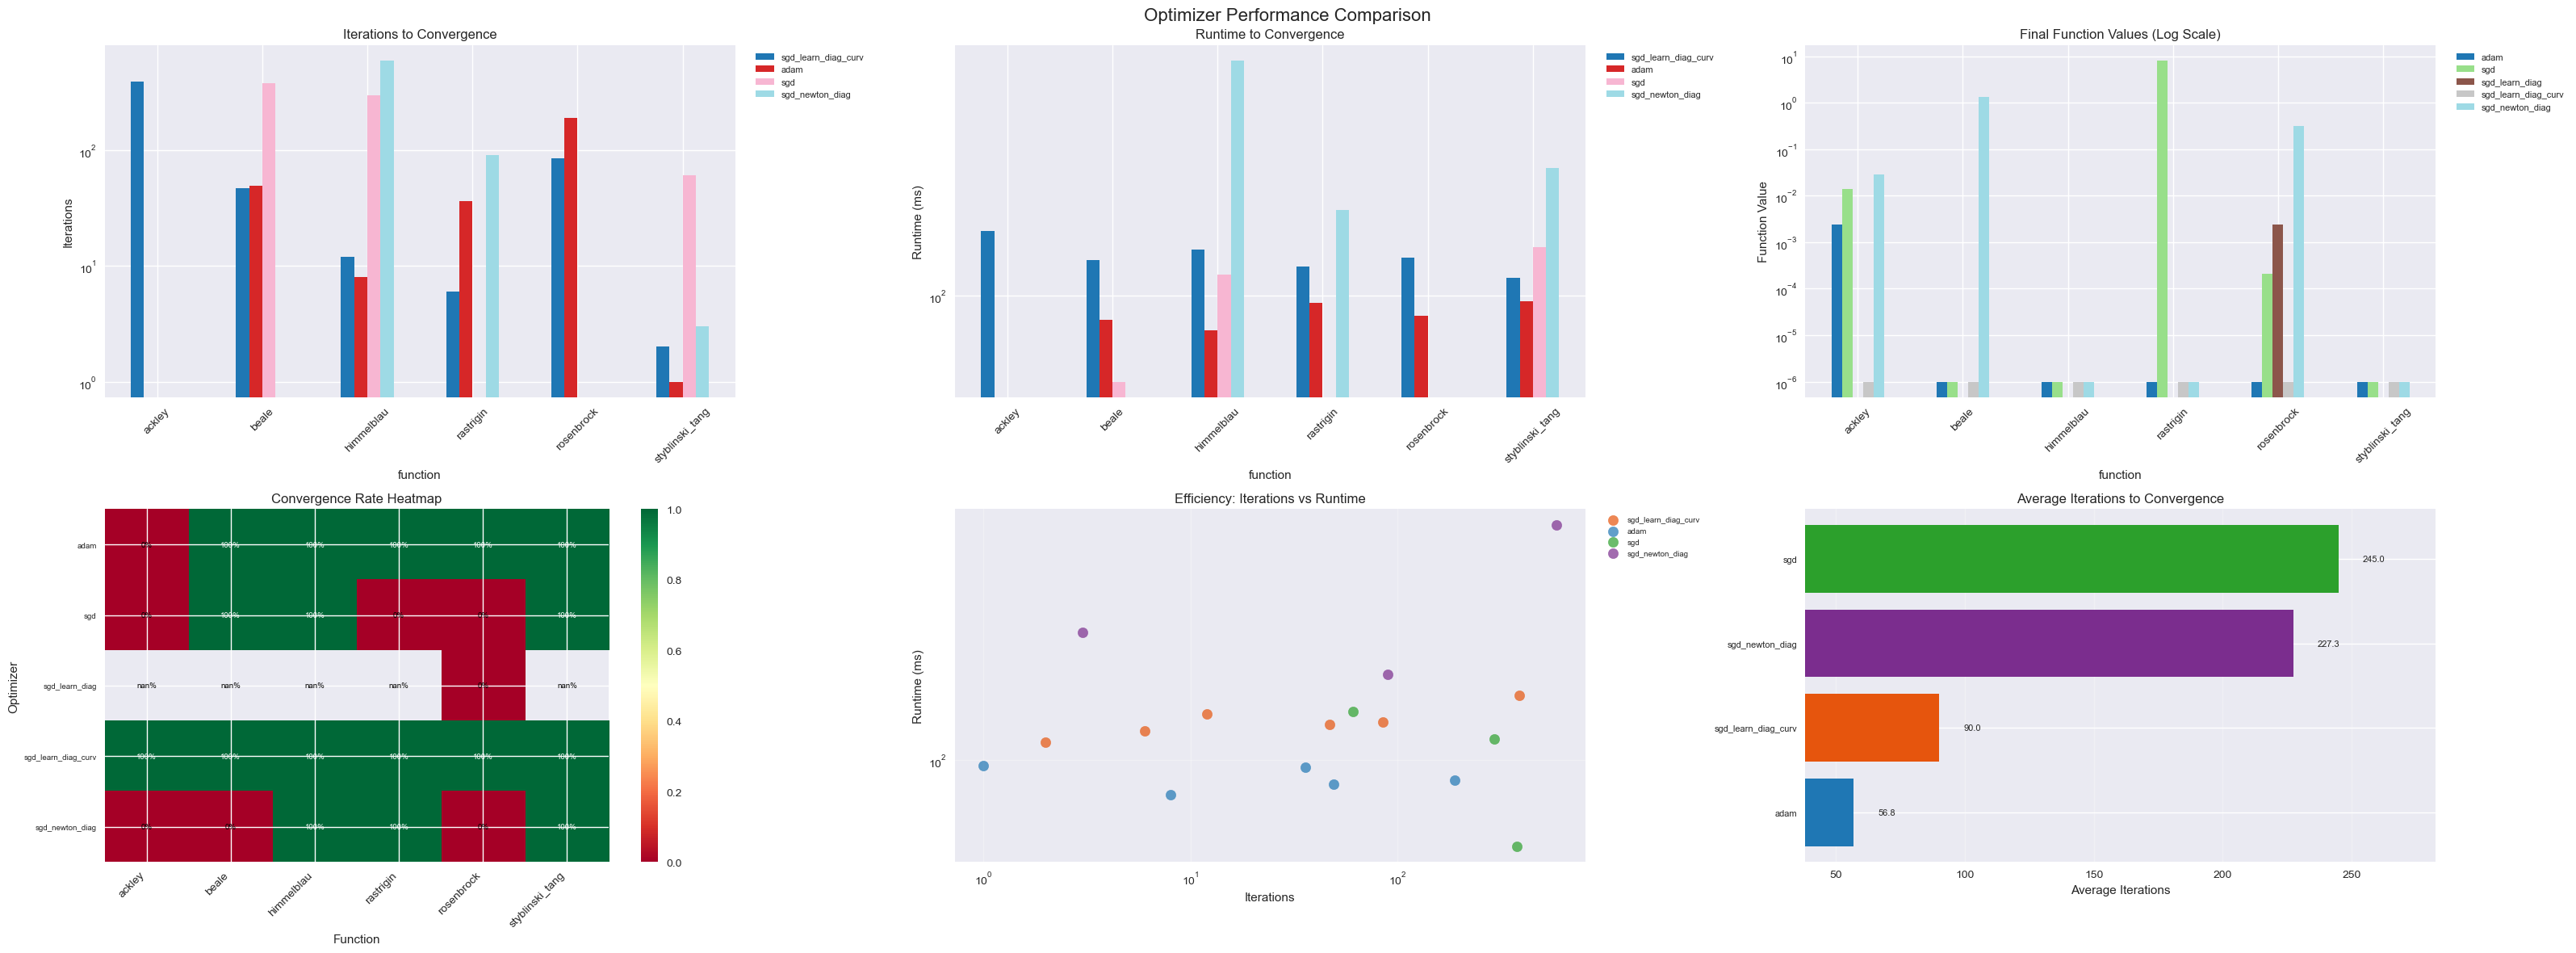

In [6]:
if len(summary_df) == 0:
    print("No results to plot.")
else:
    fig = plot_multi_function_performance(summary_df)
    plt.show()

# Convergence Curves


/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/repo/analysis/plots.py:422: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/repo/analysis/plots.py:422: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/.conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/.conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


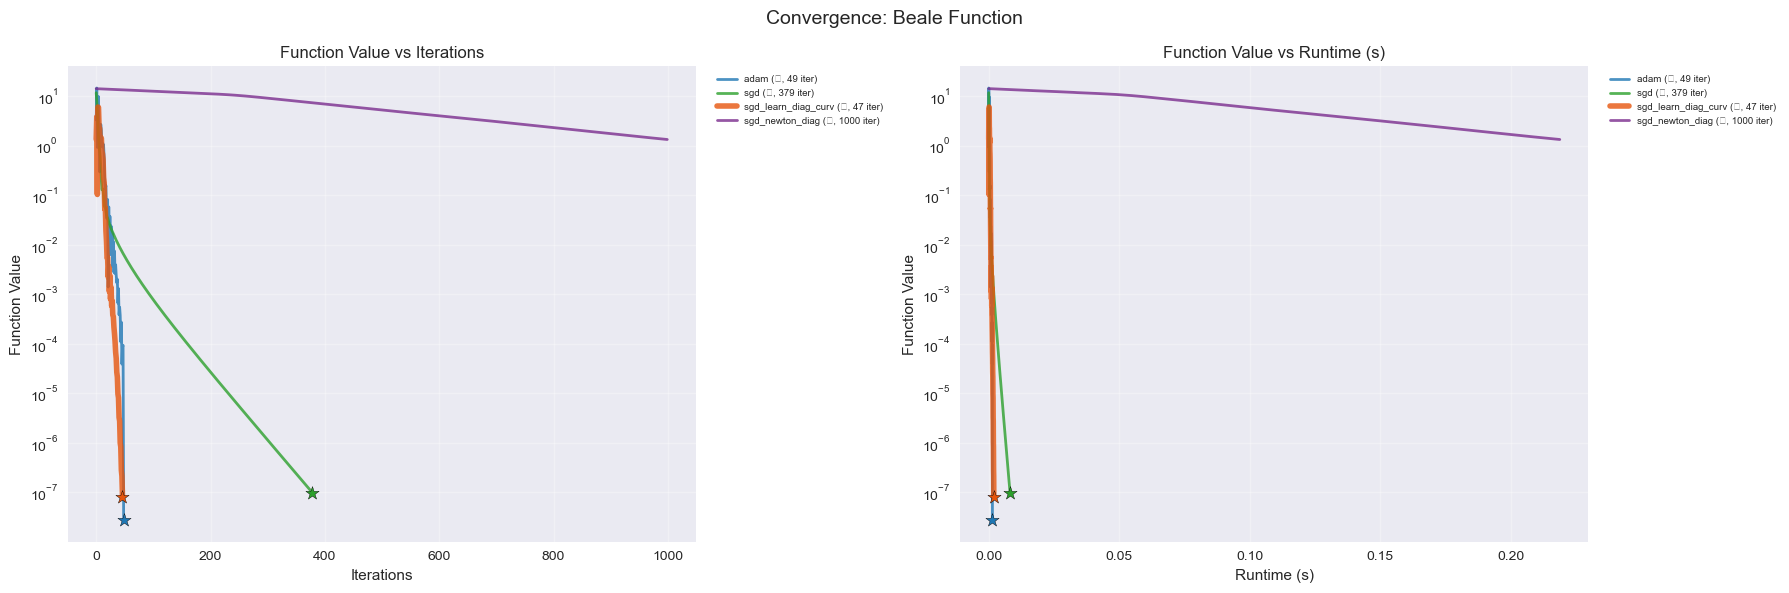


Beale Function Summary:
------------------------------------------------------------
  adam                     : Converged  |   49 iter |   81.6 ms | Final: 2.73e-08
  sgd                      : Converged  |  379 iter |   48.6 ms | Final: 9.85e-08
  sgd_learn_diag_curv      : Converged  |   47 iter |  134.4 ms | Final: 8.17e-08
  sgd_newton_diag          : Failed     | 1000 iter |  847.2 ms | Final: 1.33e+00


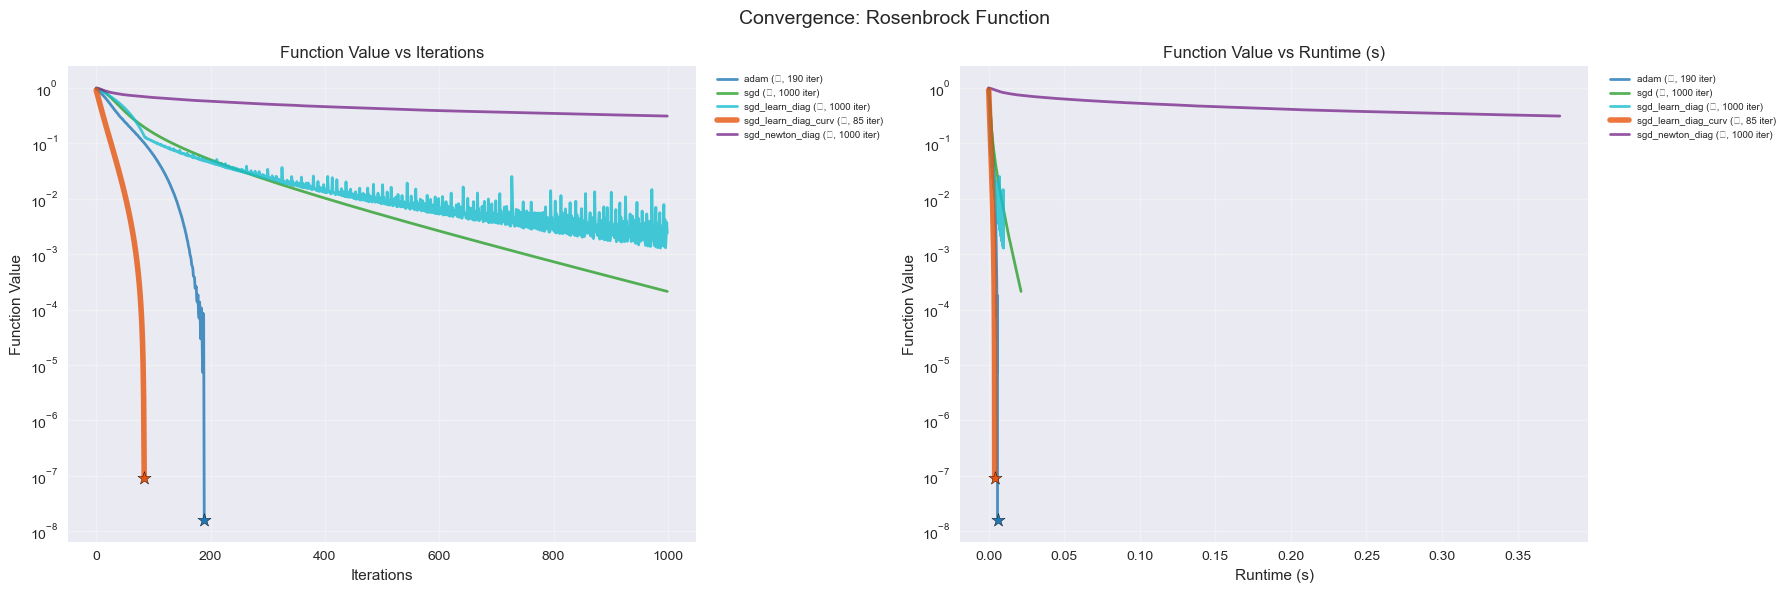


Rosenbrock Function Summary:
------------------------------------------------------------
  adam                     : Converged  |  190 iter |   84.4 ms | Final: 1.58e-08
  sgd                      : Failed     | 1000 iter |  134.9 ms | Final: 2.12e-04
  sgd_learn_diag           : Failed     | 1000 iter |   36.7 ms | Final: 2.41e-03
  sgd_learn_diag_curv      : Converged  |   85 iter |  137.3 ms | Final: 9.02e-08
  sgd_newton_diag          : Failed     | 1000 iter | 1163.0 ms | Final: 3.11e-01


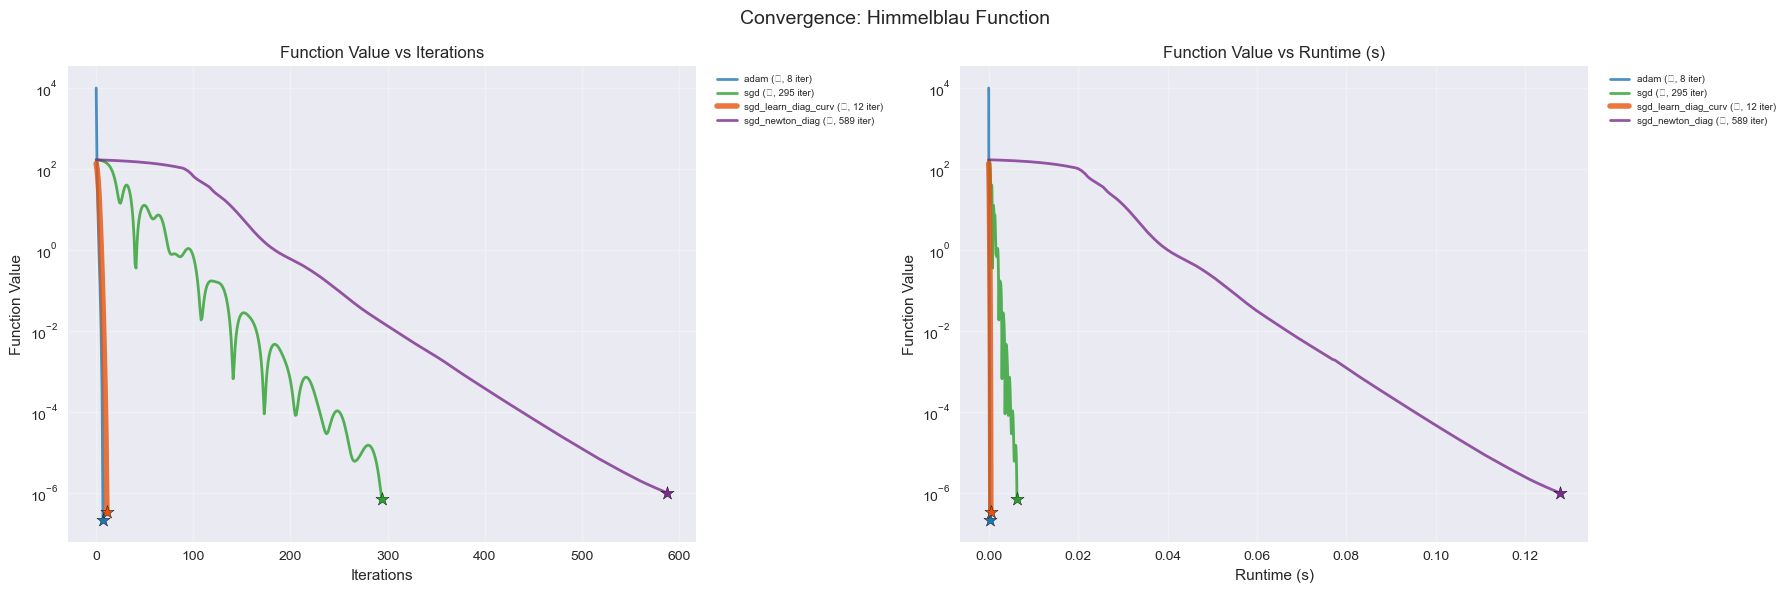


Himmelblau Function Summary:
------------------------------------------------------------
  adam                     : Converged  |    8 iter |   74.8 ms | Final: 2.10e-07
  sgd                      : Converged  |  295 iter |  119.5 ms | Final: 7.14e-07
  sgd_learn_diag_curv      : Converged  |   12 iter |  147.4 ms | Final: 3.35e-07
  sgd_newton_diag          : Converged  |  589 iter |  715.1 ms | Final: 9.74e-07


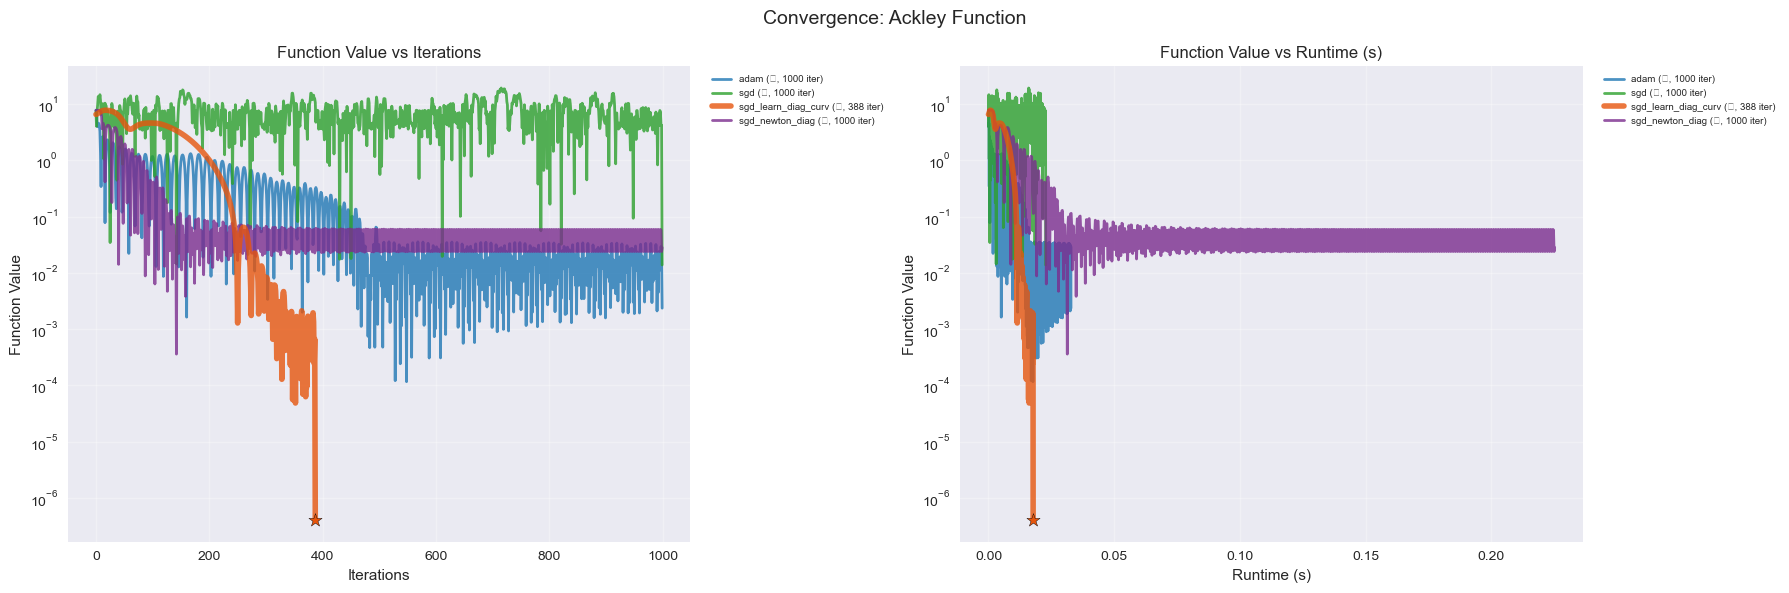


Ackley Function Summary:
------------------------------------------------------------
  adam                     : Failed     | 1000 iter |  127.1 ms | Final: 2.36e-03
  sgd                      : Failed     | 1000 iter |   70.3 ms | Final: 1.39e-02
  sgd_learn_diag_curv      : Converged  |  388 iter |  171.5 ms | Final: 4.04e-07
  sgd_newton_diag          : Failed     | 1000 iter |  481.1 ms | Final: 2.82e-02


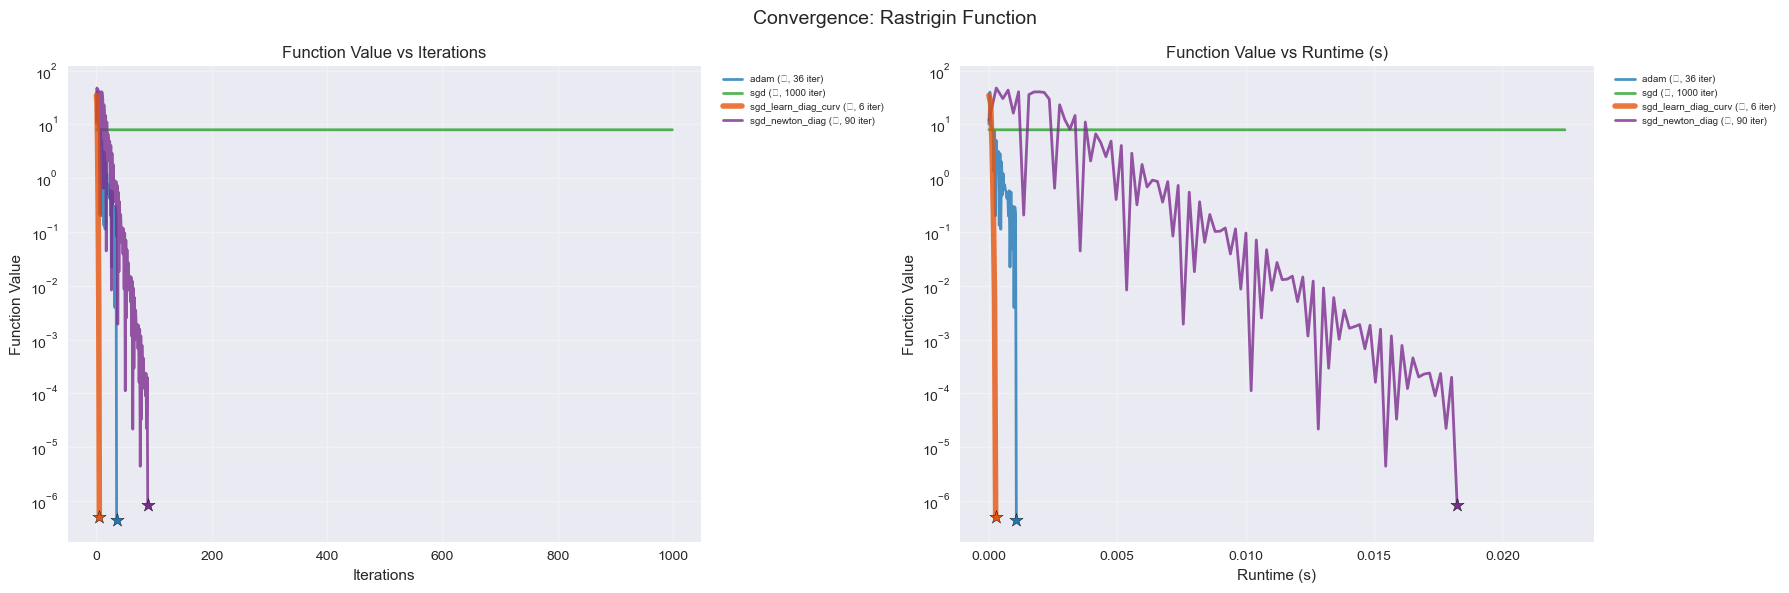


Rastrigin Function Summary:
------------------------------------------------------------
  adam                     : Converged  |   36 iter |   94.0 ms | Final: 4.43e-07
  sgd                      : Failed     | 1000 iter |  134.7 ms | Final: 7.96e+00
  sgd_learn_diag_curv      : Converged  |    6 iter |  127.3 ms | Final: 5.17e-07
  sgd_newton_diag          : Converged  |   90 iter |  204.5 ms | Final: 8.42e-07


/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/repo/analysis/plots.py:408: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.scatter(
/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/repo/analysis/plots.py:422: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


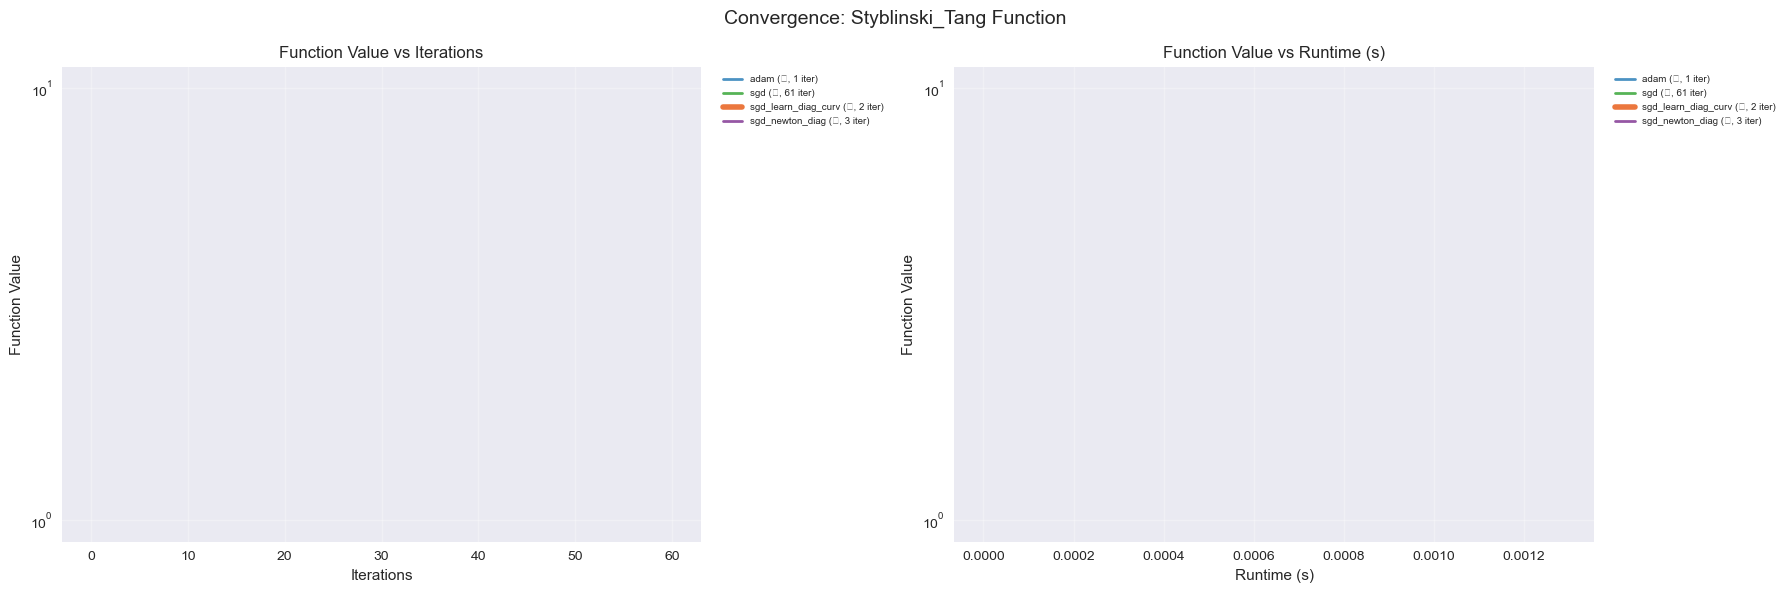


Styblinski_Tang Function Summary:
------------------------------------------------------------
  adam                     : Converged  |    1 iter |   95.6 ms | Final: -7.83e+01
  sgd                      : Converged  |   61 iter |  150.0 ms | Final: -7.81e+01
  sgd_learn_diag_curv      : Converged  |    2 iter |  116.2 ms | Final: -7.83e+01
  sgd_newton_diag          : Converged  |    3 iter |  290.6 ms | Final: -7.83e+01


In [7]:
HIGHLIGHT = ["sgd_learn_diag_curv", "sgd_learn_diag_curv_log"]

for func_name in FUNCTIONS:
    best_runs = all_best_runs[func_name]
    if not best_runs:
        continue

    history_data = all_history_data[func_name]

    fig = plot_convergence_curves(
        history_data,
        y_keys=["function_value"],
        x_keys=["epoch", "wall_times"],
        best_runs=best_runs,
        converged_key="converged",
        best_epoch_key="iterations",
        colors=colors,
        highlight=HIGHLIGHT,
        title=f'Convergence: {func_name.title()} Function',
        y_labels={"function_value": "Function Value"},
        x_labels={"epoch": "Iterations", "wall_times": "Runtime (s)"},
    )
    plt.show()

    print_convergence_summary(best_runs, func_name=func_name, optimizers=OPTIMIZERS)

# HP Sensitivity

In [8]:
all_runs_by_func = {}
for func_name in FUNCTIONS:
    task_tag = f"small_examples_{func_name}"
    all_runs_by_func[func_name] = load_all_runs(
        backend=BACKEND,
        optimizers=OPTIMIZERS,
        task_tag=task_tag,
        results_dir=RESULTS_DIR,
        iteration=ITERATION,
    )

Loading all runs for adam...


  adam: 1000 runs
Loading all runs for sgd...


  sgd: 1000 runs
Loading all runs for sgd_learn_diag...
  sgd_learn_diag: 0 runs
Loading all runs for sgd_learn_diag_curv...


  sgd_learn_diag_curv: 1000 runs
Loading all runs for sgd_newton_diag...


  sgd_newton_diag: 1000 runs
Loading all runs for adam...


...

  sgd_newton_diag: 1000 runs
Loading all runs for adam...
  adam: 1000 runs
Loading all runs for sgd...


  sgd: 1000 runs
Loading all runs for sgd_learn_diag...
  sgd_learn_diag: 0 runs
Loading all runs for sgd_learn_diag_curv...
  sgd_learn_diag_curv: 1000 runs
Loading all runs for sgd_newton_diag...


  sgd_newton_diag: 1000 runs
Loading all runs for adam...
  adam: 1000 runs
Loading all runs for sgd...


  sgd: 1000 runs
Loading all runs for sgd_learn_diag...
  sgd_learn_diag: 0 runs
Loading all runs for sgd_learn_diag_curv...
  sgd_learn_diag_curv: 1000 runs
Loading all runs for sgd_newton_diag...


  sgd_newton_diag: 1000 runs


In [9]:
# for func_name in FUNCTIONS:
#     for opt in OPTIMIZERS:
#         runs = all_runs_by_func[func_name].get(opt, [])
#         if len(runs) >= 5:
#             fig, axes = plot_hp_sensitivity(
#                 runs, opt,
#                 metric_key='sweep_metric',
#                 direction='minimize',
#             )
#             fig.suptitle(f'{func_name} — {opt}', fontsize=14)
#             plt.show()

# Text-Based Analysis (Paper-Ready Tables)

In [10]:
# Per-function ranking tables and variant comparisons
for func_name in FUNCTIONS:
    br = all_best_runs.get(func_name, {})
    if not br:
        continue
    print_ranking_table(br, metric_key="sweep_metric", direction="minimize",
                        title=f'{func_name.title()} — Optimizer Ranking')
    print_variant_comparison(br, metric_key="sweep_metric", direction="minimize",
                             title=f'{func_name.title()} — Variant Pairs')
    print_offdiag_ranking(br, metric_key="sweep_metric", direction="minimize",
                          title=f'{func_name.title()} — Off-Diagonal Ranking')


Beale — Optimizer Ranking
Rank  Optimizer                     sweep_metric        
--------------------------------------------------------
1     sgd_learn_diag_curv           0.470000            
2     adam                          0.490000            
3     sgd                           3.790000            
4     sgd_newton_diag               111.327820          


Beale — Variant Pairs
Comparison                         Base        Variant     Delta       Winner      
-----------------------------------------------------------------------------------

  (no off-diagonal optimizers found)

Rosenbrock — Optimizer Ranking
Rank  Optimizer                     sweep_metric        
--------------------------------------------------------
1     sgd_learn_diag_curv           0.850000            
2     adam                          1.900000            
3     sgd                           110.000212          
4     sgd_learn_diag                110.002411          
5     sgd_newton_diag      

In [11]:
# Overall rankings using ALL runs (not just best) across all functions
print("=" * 80)
print("OVERALL RANKINGS (all runs, all functions)")
print("=" * 80)

# Build summary from all runs
all_rows = []
for func_name in FUNCTIONS:
    for opt, runs in all_runs_by_func.get(func_name, {}).items():
        for r in runs:
            s = r.get("summary", {})
            all_rows.append({
                "function": func_name,
                "optimizer": opt,
                "converged": s.get("converged", False),
                "iterations": s.get("iterations", None),
                "runtime_seconds": s.get("runtime_seconds", None),
                "final_value": s.get("final_value", None),
                "sweep_metric": s.get("sweep_metric", None),
            })

all_runs_df = pd.DataFrame(all_rows)

print(f"\nTotal runs: {len(all_runs_df)}")
print(f"Functions: {all_runs_df['function'].nunique()}")
print(f"Optimizers: {all_runs_df['optimizer'].nunique()}")

print("\n1. BY CONVERGENCE RATE (all runs):")
conv_rate = all_runs_df.groupby('optimizer')['converged'].mean().sort_values(ascending=False)
for i, (opt, rate) in enumerate(conv_rate.items(), 1):
    n = all_runs_df[all_runs_df['optimizer'] == opt].shape[0]
    print(f"  {i:2d}. {opt:30s}: {rate:.1%}  (n={n})")

converged = all_runs_df[all_runs_df['converged'] == True]
if len(converged) > 0:
    print("\n2. BY AVERAGE ITERATIONS (converged runs only):")
    avg_iter = converged.groupby('optimizer')['iterations'].mean().sort_values()
    std_iter = converged.groupby('optimizer')['iterations'].std()
    n_conv = converged.groupby('optimizer').size()
    for i, (opt, val) in enumerate(avg_iter.items(), 1):
        s = std_iter.get(opt, 0)
        n = n_conv.get(opt, 0)
        print(f"  {i:2d}. {opt:30s}: {val:6.1f} +/- {s:5.1f}  (n={n})")

    print("\n3. BY AVERAGE RUNTIME (converged runs only):")
    converged_rt = converged.dropna(subset=['runtime_seconds'])
    if len(converged_rt) > 0:
        converged_rt = converged_rt.copy()
        converged_rt['runtime_ms'] = converged_rt['runtime_seconds'] * 1000
        avg_rt = converged_rt.groupby('optimizer')['runtime_ms'].mean().sort_values()
        for i, (opt, val) in enumerate(avg_rt.items(), 1):
            print(f"  {i:2d}. {opt:30s}: {val:6.1f} ms")

OVERALL RANKINGS (all runs, all functions)

Total runs: 24050
Functions: 6
Optimizers: 5

1. BY CONVERGENCE RATE (all runs):
   1. adam                          : 39.9%  (n=6000)
   2. sgd_learn_diag_curv           : 37.4%  (n=6000)
   3. sgd_newton_diag               : 2.3%  (n=6000)
   4. sgd                           : 0.8%  (n=6000)
   5. sgd_learn_diag                : 0.0%  (n=50)

2. BY AVERAGE ITERATIONS (converged runs only):
   1. sgd                           :   99.1 +/- 212.1  (n=47)
   2. sgd_newton_diag               :  153.6 +/- 246.7  (n=137)
   3. sgd_learn_diag_curv           :  166.6 +/- 224.0  (n=2244)
   4. adam                          :  193.2 +/- 261.6  (n=2396)

3. BY AVERAGE RUNTIME (converged runs only):
   1. sgd                           :   45.3 ms
   2. adam                          :   96.2 ms
   3. sgd_learn_diag_curv           :  148.6 ms
   4. sgd_newton_diag               :  283.2 ms


In [12]:
# Statistical variant comparison and HP sensitivity (across all functions)
for func_name in FUNCTIONS:
    ar = all_runs_by_func.get(func_name, {})
    if not ar:
        continue
    print_variant_comparison_allruns(ar, metric_key="sweep_metric", direction="minimize",
                                     title=f'{func_name.title()} — Variant Comparison (Mann-Whitney U)')

# HP sensitivity for curv variants (pooled across functions)
for opt in ['sgd_learn_diag_curv', 'sgd_learn_diag_curv_log']:
    pooled = []
    for func_name in FUNCTIONS:
        pooled.extend(all_runs_by_func.get(func_name, {}).get(opt, []))
    if len(pooled) >= 10:
        print_hp_sensitivity_table(pooled, metric_key="sweep_metric",
                                   title=f'HP Sensitivity (pooled across functions) — {opt}')


Beale — Variant Comparison (Mann-Whitney U)
Comparison                    Base med   Var med    n_base  n_var   U           r       Effect      p-value   Sig?  
--------------------------------------------------------------------------------------------------------------------


Rosenbrock — Variant Comparison (Mann-Whitney U)
Comparison                    Base med   Var med    n_base  n_var   U           r       Effect      p-value   Sig?  
--------------------------------------------------------------------------------------------------------------------
curvature correction          110.861004 110.027240 1000    50      10471       +0.581  large       0.0000    ***   


Himmelblau — Variant Comparison (Mann-Whitney U)
Comparison                    Base med   Var med    n_base  n_var   U           r       Effect      p-value   Sig?  
--------------------------------------------------------------------------------------------------------------------


Ackley — Variant Comparison (Man

/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/repo/analysis/tables.py:341: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(vals, perf)


In [13]:
# Statistical variant comparison (all runs, pooled across functions)
# Pool runs from all functions for each optimizer
pooled_runs = {}
for func_name in FUNCTIONS:
    for opt, runs in all_runs_by_func.get(func_name, {}).items():
        pooled_runs.setdefault(opt, []).extend(runs)

print_variant_comparison_allruns(pooled_runs, metric_key="sweep_metric", direction="minimize",
                                 title='Small Examples (pooled) — Variant Comparison (Mann-Whitney U)')

# HP sensitivity for key variants (pooled)
for opt in ['sgd_learn_diag_curv', 'sgd_learn_diag_curv_log', 'sgd_learn_diag', 'adam', 'sgd']:
    runs = pooled_runs.get(opt, [])
    if len(runs) >= 10:
        print_hp_sensitivity_table(runs, metric_key="sweep_metric",
                                   title=f'HP Sensitivity (pooled) — {opt}')


Small Examples (pooled) — Variant Comparison (Mann-Whitney U)
Comparison                    Base med   Var med    n_base  n_var   U           r       Effect      p-value   Sig?  
--------------------------------------------------------------------------------------------------------------------
curvature correction          110.861004 110.010057 5999    50      102963      +0.313  medium      0.0001    ***   


HP Sensitivity (pooled) — sgd_learn_diag_curv
HP                       Spearman rho   p-value     Sig?  Direction   
----------------------------------------------------------------------
momentum                 +0.281         0.0000      ***   higher=better
curv_tau                 -0.208         0.0000      ***   lower=better
max_condition_number     +0.194         0.0000      ***   higher=better
metric_reg               +0.187         0.0000      ***   higher=better
xi                       +0.150         0.0000      ***   higher=better
metric_lr                +0.149      

# Budget-Aware Statistical Analysis

Bootstrap CIs on best-run, top-k comparison, robustness metrics, and
best-of-budget incumbent curves. These use the pooled runs across all
test functions to control for the maximum order statistic problem.

In [14]:
# Bootstrap CI on best-run (pooled across functions)
bootstrap_best_run_ci(pooled_runs, metric_key="sweep_metric", direction="minimize",
                      title=f'Small Examples (pooled, itr {ITERATION}) — Bootstrap 95% CI on Best Run')

# Top-k mean comparison (pooled)
print_topk_comparison(pooled_runs, metric_key="sweep_metric", direction="minimize",
                      title=f'Small Examples (pooled, itr {ITERATION}) — Top-k Mean Comparison')

# Robustness table (pooled)
print_robustness_table(pooled_runs, metric_key="sweep_metric", direction="minimize",
                       title=f'Small Examples (pooled, itr {ITERATION}) — Robustness Metrics')


Small Examples (pooled, itr 4) — Bootstrap 95% CI on Best Run
Optimizer                     Best        CI lo       CI hi       n_runs  
--------------------------------------------------------------------------


adam                          -78.322041  -78.322041  -78.310311  6000    
sgd                           -78.302265  -78.302265  -78.239763  2003    
sgd_learn_diag                110.002411  110.002411  110.012462  50      


sgd_learn_diag_curv           -78.312323  -78.312323  -78.301190  5999    
sgd_newton_diag               -78.297701  -78.297701  -78.254764  2185    


Small Examples (pooled, itr 4) — Top-k Mean Comparison
Optimizer                     top-1         top-5         top-10        top-50        n_runs  
----------------------------------------------------------------------------------------------
adam                          -78.322041    -78.313932    -78.307967    -78.284373    6000    
sgd_learn_diag_curv           -78.312323    -78.306747    -78.301668    -78.279270    5999    
sgd                           -78.302265    -78.260171    -78.212229    2.040164      2003    
sgd_newton_diag               -78.297701    -78.271387    -78.247173    -66.713921    2185    
sgd_learn_diag                110.002411    110.012666    110.114851    122.454347    50      


Small Examples (pooled, itr 4) — Robustness Metrics
  Failure threshold: 130.827257 (> = failure)
Optimizer                   

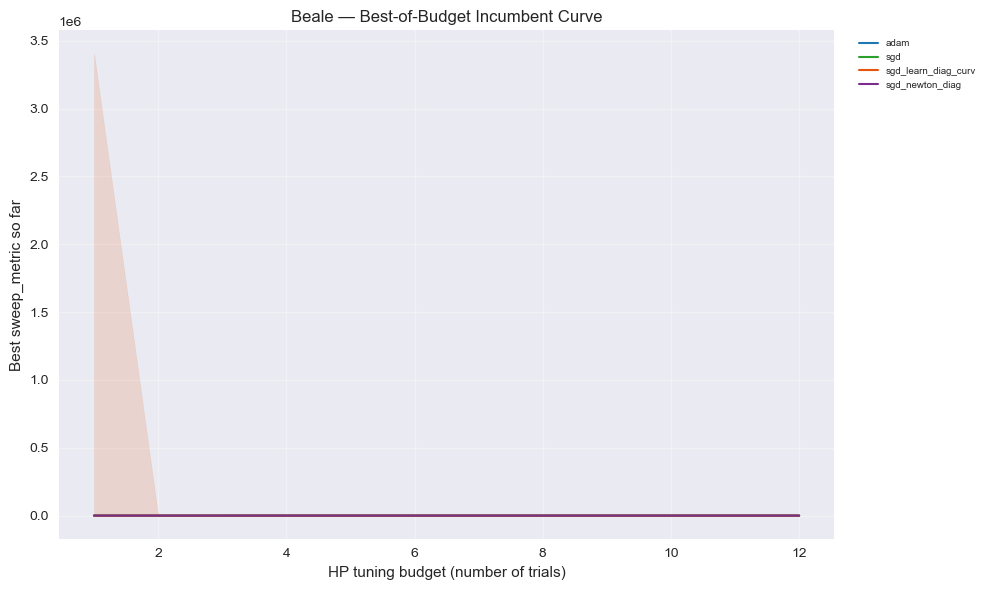

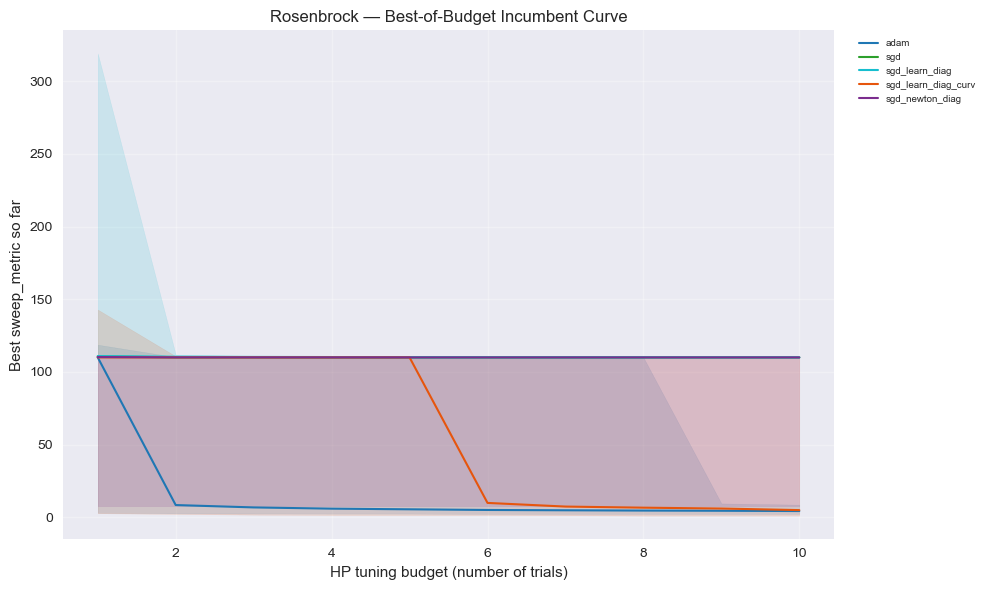

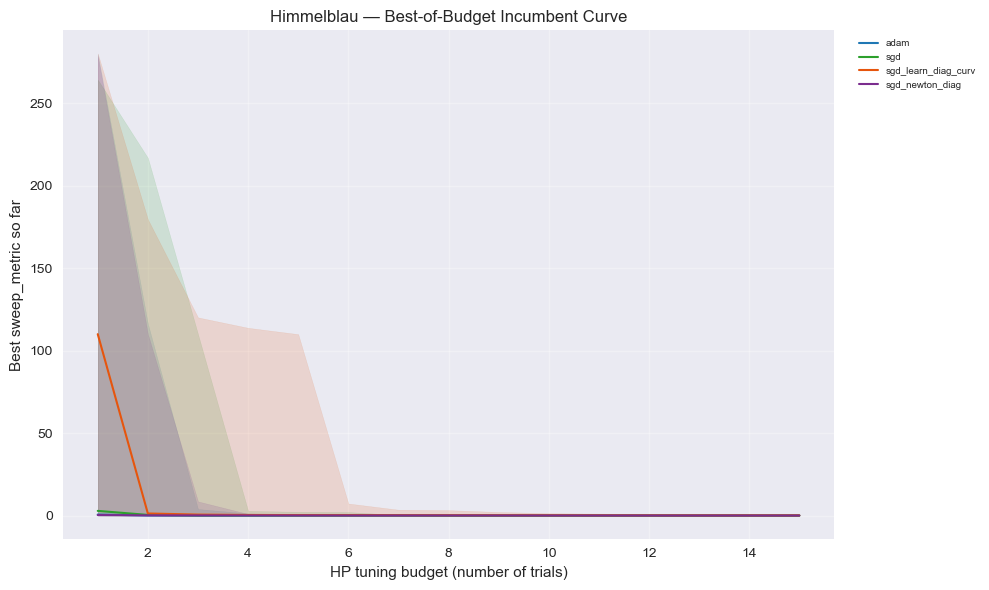

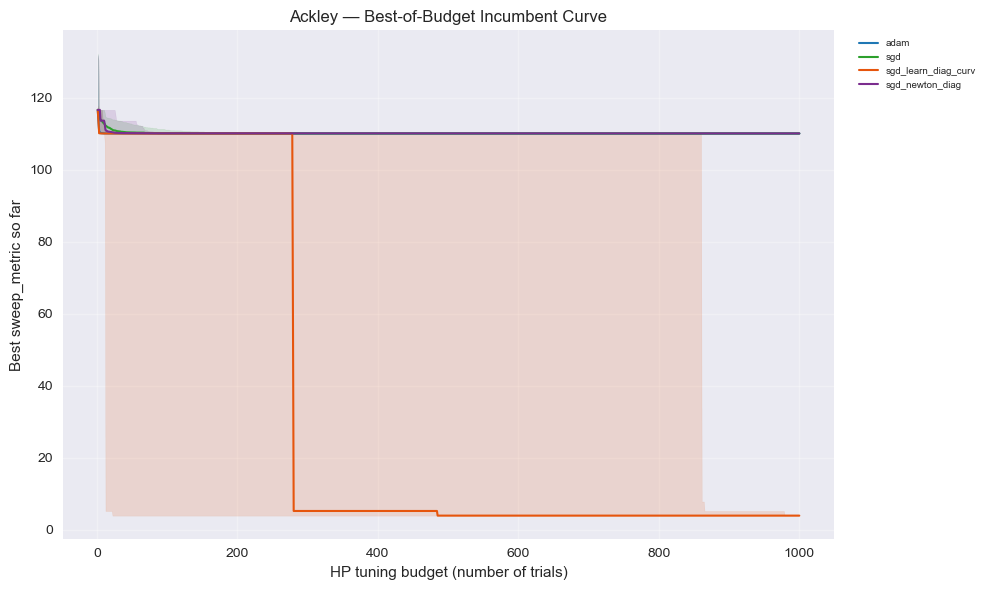

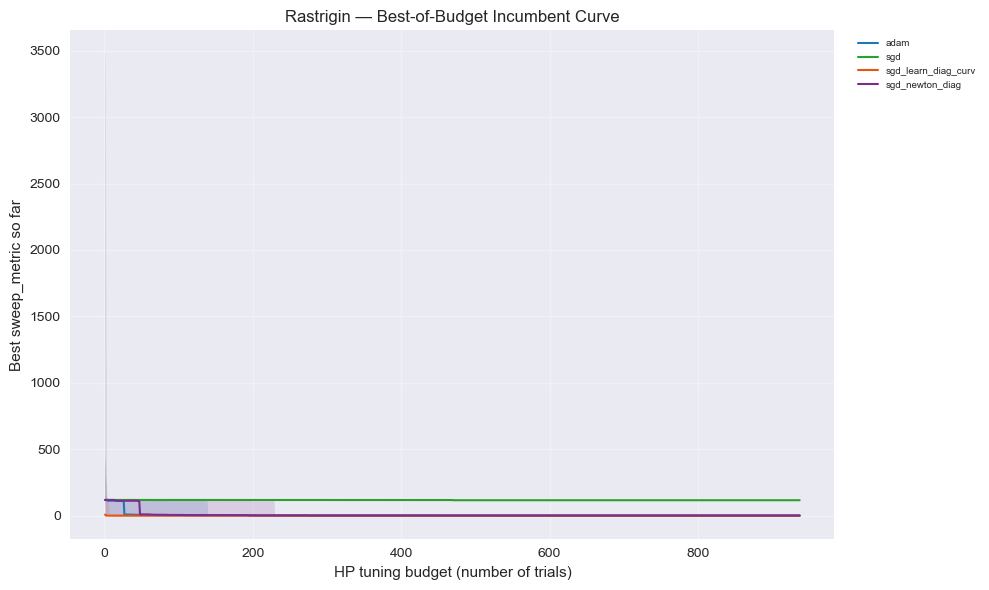

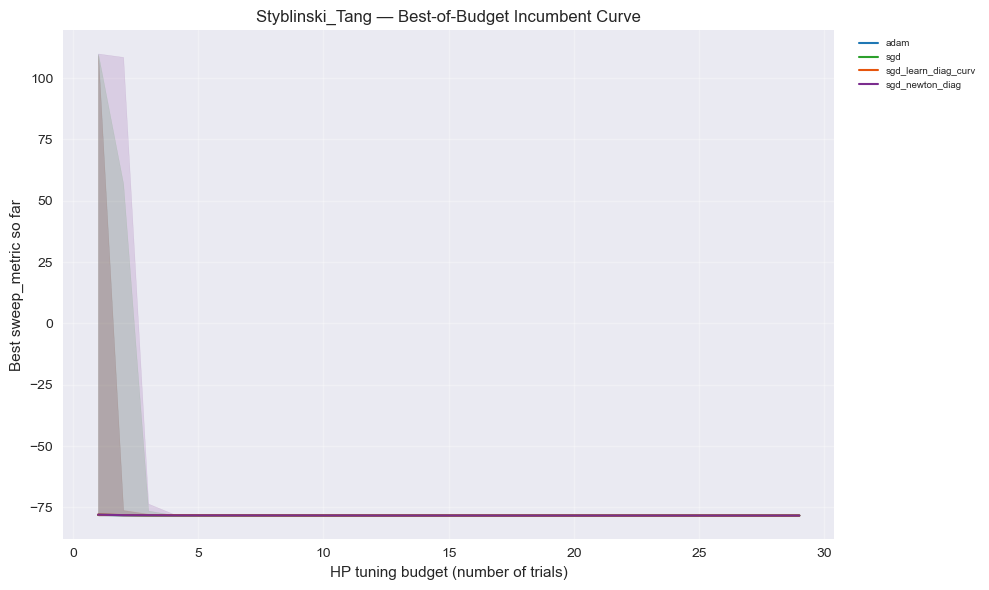

In [15]:
# Best-of-budget incumbent curves (per function)
for func_name in FUNCTIONS:
    ar = all_runs_by_func.get(func_name, {})
    if not ar:
        continue
    fig = plot_best_of_budget(ar, metric_key="sweep_metric", direction="minimize",
                              title=f'{func_name.title()} — Best-of-Budget Incumbent Curve')
    plt.show()

# Best Hyperparameters


In [16]:
# Print and save best hyperparameters per function
all_hp_rows = []

for func_name in FUNCTIONS:
    best_runs = all_best_runs[func_name]
    if not best_runs:
        continue

    print(f"\n{'=' * 60}")
    print(f"{func_name.upper()} FUNCTION")
    print(f"{'=' * 60}")
    print_best_hyperparameters(best_runs)

    for opt, run_info in best_runs.items():
        row = {
            'function': func_name,
            'optimizer': opt,
            'run_name': run_info.get('name', 'unknown'),
        }
        row.update(run_info.get('config', {}))
        row.update(run_info.get('summary', {}))
        all_hp_rows.append(row)

df = pd.DataFrame(all_hp_rows)
filename = f'best_hyperparameters_SmallExamples_itr_{ITERATION}.csv'
df.to_csv(filename, index=False)
print(f"\nSaved all hyperparameters to {filename}")
df


BEALE FUNCTION
Hyperparameters for Best Runs

ADAM:
  Run name: run_320
  Config:
    learning_rate: 1.1873582130872948
    beta1: 0.7600366252989305
    beta2: 0.9661037943741666
    eps: 3.747197105448695e-09
    max_iterations: 1000
  sweep_metric: 0.490000
----------------------------------------

SGD:
  Run name: run_374
  Config:
    learning_rate: 0.01636191330880527
    momentum: 0.670476860490933
    max_iterations: 1000
  sweep_metric: 3.790000
----------------------------------------

SGD_LEARN_DIAG_CURV:
  Run name: run_638
  Config:
    learning_rate: 0.21913481549290453
    momentum: 0.6479186871322821
    xi: 0.004283406534508938
    beta: 0.7451139364279569
    weight_decay: 1.0104284015370414e-06
    metric_lr: 0.9728665662433181
    metric_reg: 7.508929664163431e-05
    metric_clip: 3.1856888987372582
    curv_beta: 0.0066147861211764926
    curv_tau: 5.5923574216948175
    metric_param: exp_matched_reg
    max_iterations: 1000
  sweep_metric: 0.470000
--------------

,function,optimizer,run_name,learning_rate,beta1,beta2,eps,max_iterations,total_training_time_sec,total_training_time_min,...,beta,weight_decay,metric_lr,metric_reg,metric_clip,curv_beta,curv_tau,metric_param,beta_s,hess_eps
0,beale,adam,run_320,1.187358,0.760037,0.966104,3.747197e-09,1000,0.181489,0.003025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,beale,sgd,run_374,0.016362,NaN,NaN,NaN,1000,0.500144,0.008336,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,beale,sgd_learn_diag_curv,run_638,0.219135,NaN,NaN,NaN,1000,0.413464,0.006891,...,0.745114,0.000001,0.972867,0.000075,3.185689,0.006615,5.592357,exp_matched_reg,NaN,NaN
3,beale,sgd_newton_diag,run_0,0.000419,NaN,NaN,NaN,1000,6.121794,0.102030,...,NaN,0.000985,NaN,NaN,1.624075,NaN,NaN,NaN,0.175241,0.000001
4,rosenbrock,adam,run_322,0.010999,0.935764,0.895540,8.708336e-10,1000,0.472638,0.007877,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,rosenbrock,sgd,run_0,0.000419,NaN,NaN,NaN,1000,1.888320,0.031472,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,rosenbrock,sgd_learn_diag,run_22,0.068638,NaN,NaN,NaN,1000,0.679418,0.011324,...,0.567385,0.000051,0.000037,0.004998,4.509357,NaN,NaN,NaN,NaN,NaN
7,rosenbrock,sgd_learn_diag_curv,run_427,0.027834,NaN,NaN,NaN,1000,0.526719,0.008779,...,0.954214,0.000216,0.001891,0.000001,2.805761,0.016966,1.636776,exp_matched_reg,NaN,NaN
8,rosenbrock,sgd_newton_diag,run_0,0.000419,NaN,NaN,NaN,1000,8.342865,0.139048,...,NaN,0.000985,NaN,NaN,1.624075,NaN,NaN,NaN,0.175241,0.000001
9,himmelblau,adam,run_707,8.462094,0.030648,0.823393,2.125441e-08,1000,0.094378,0.001573,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Optimizer Diagnostics

Internal state diagnostics (requires `--diagnostics` flag during sweep).
Skips gracefully if no diagnostic data is present.

Processing adam...
Processing sgd...
Processing sgd_learn_diag_curv...
Processing sgd_newton_diag...


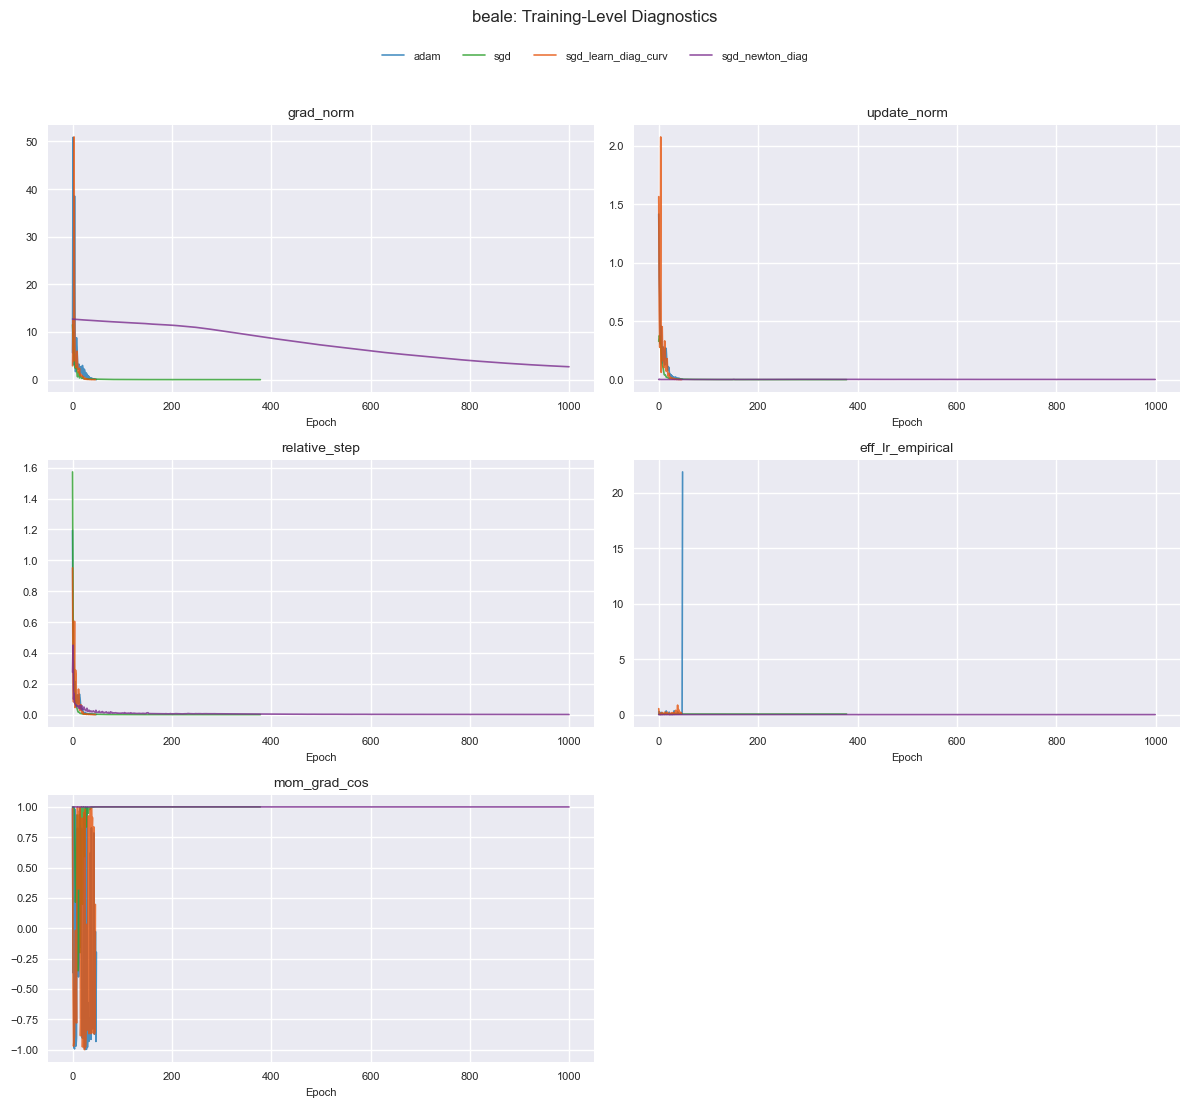

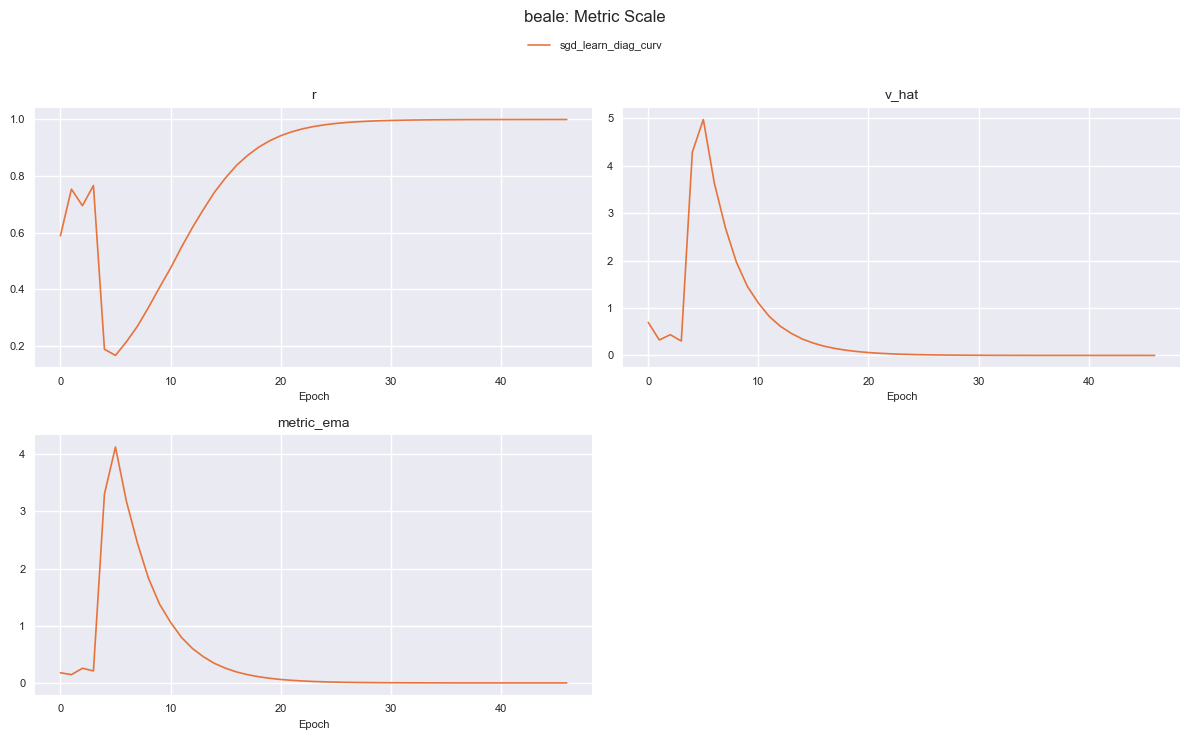

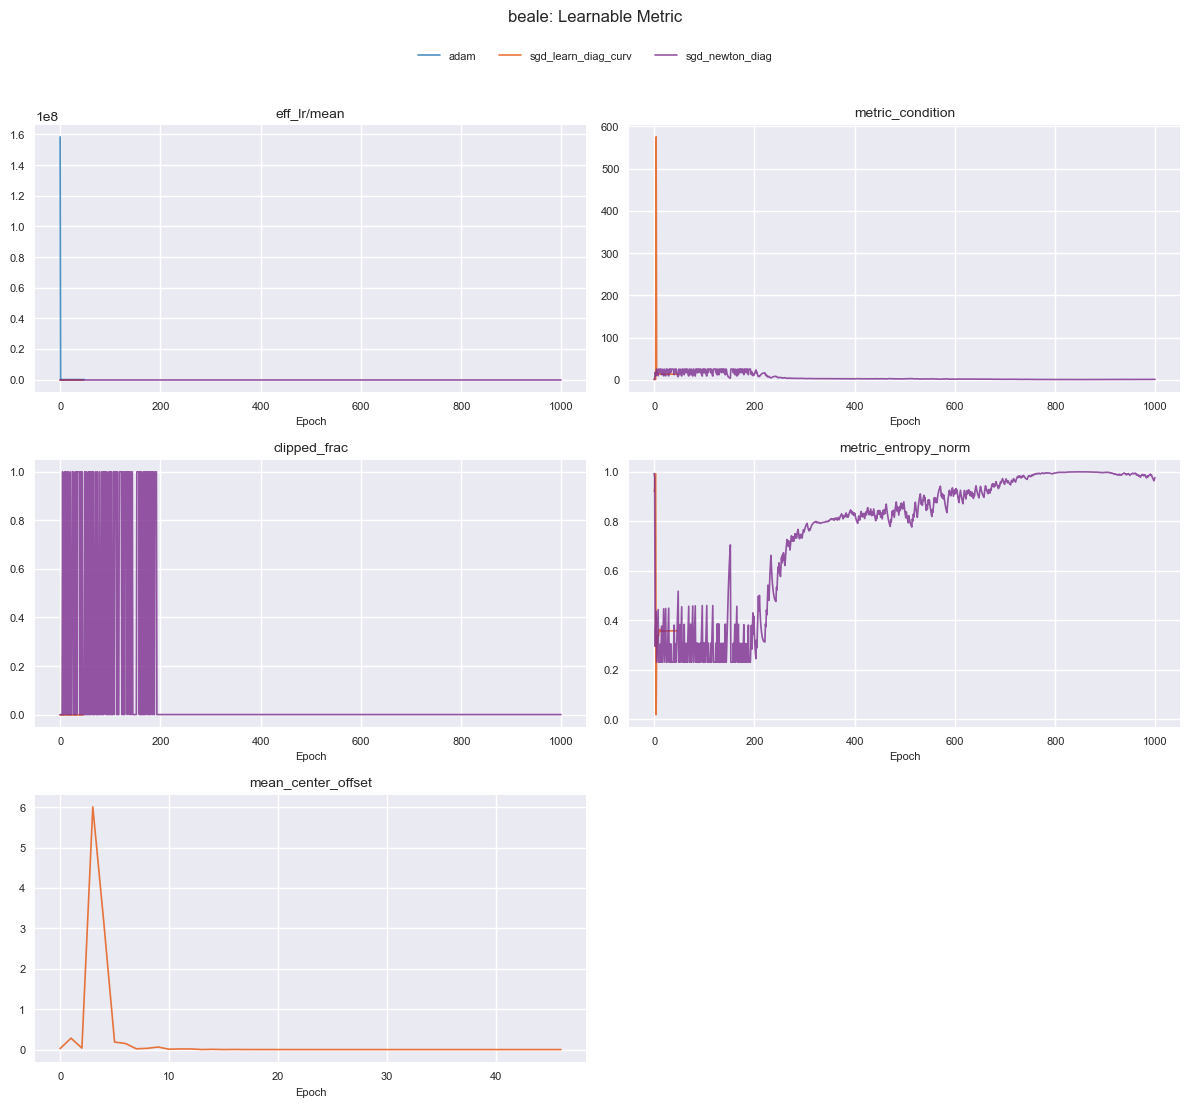

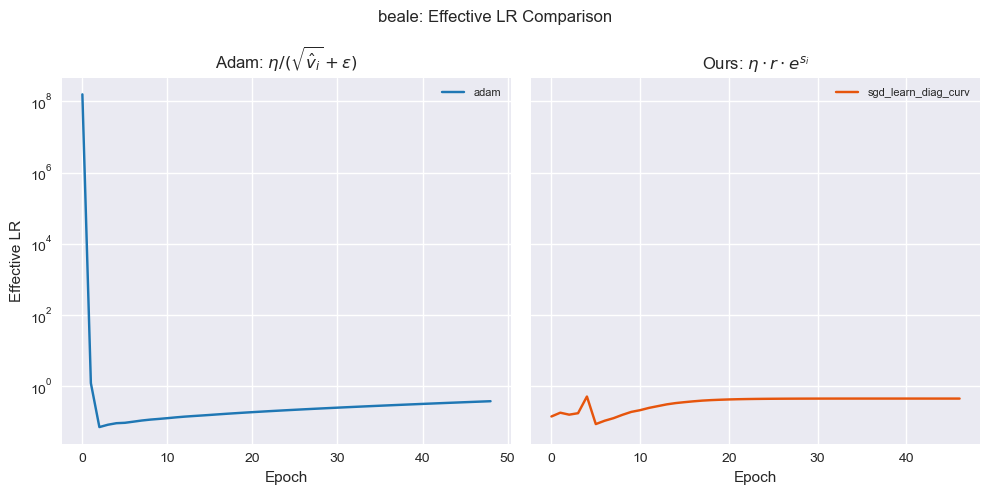

Processing adam...
Processing sgd...
Processing sgd_learn_diag...
Processing sgd_learn_diag_curv...
Processing sgd_newton_diag...


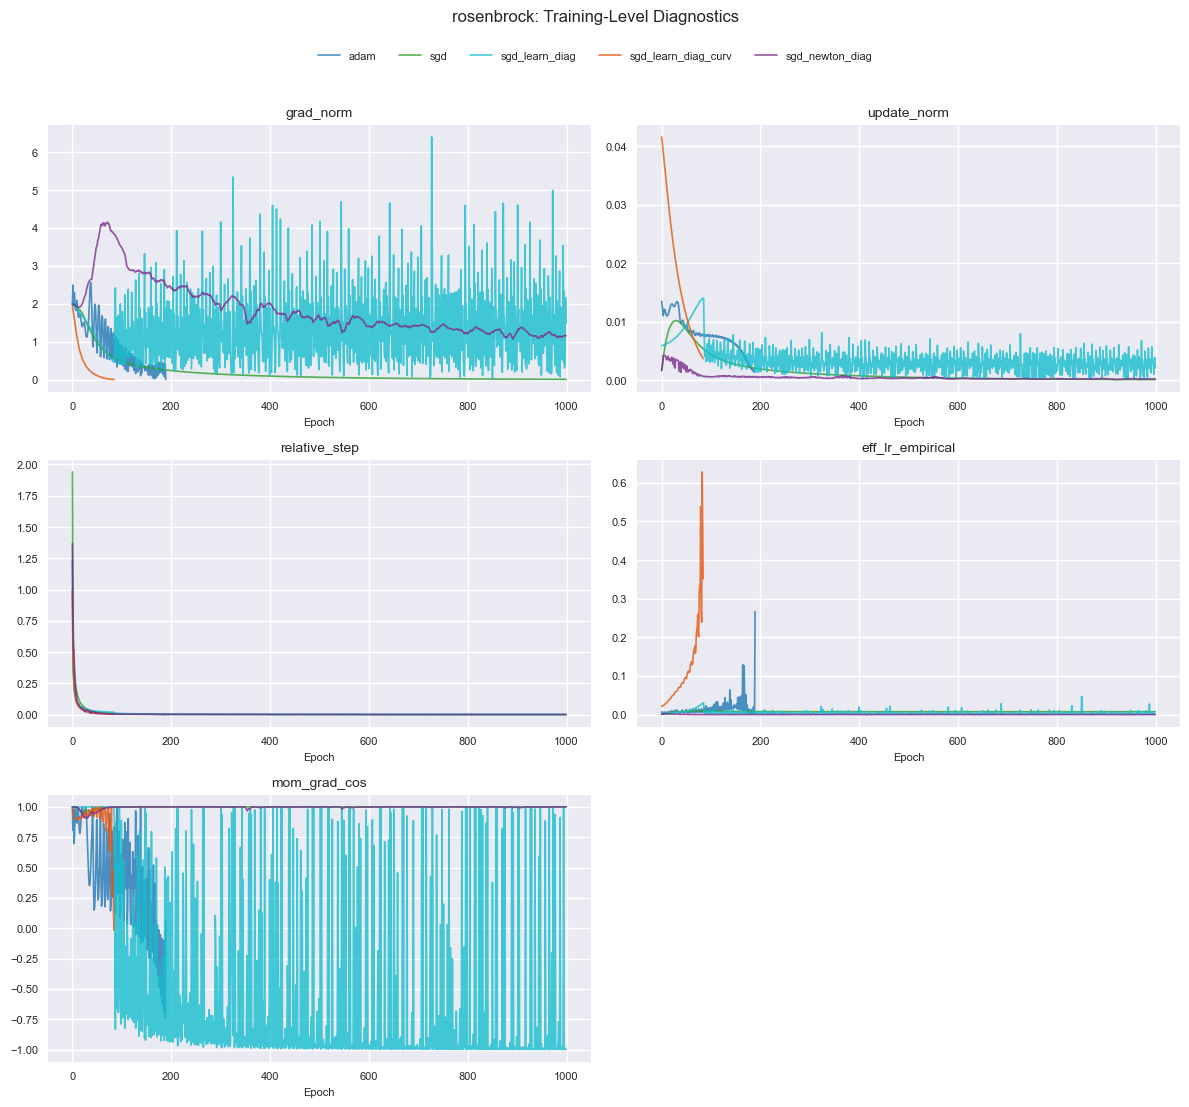

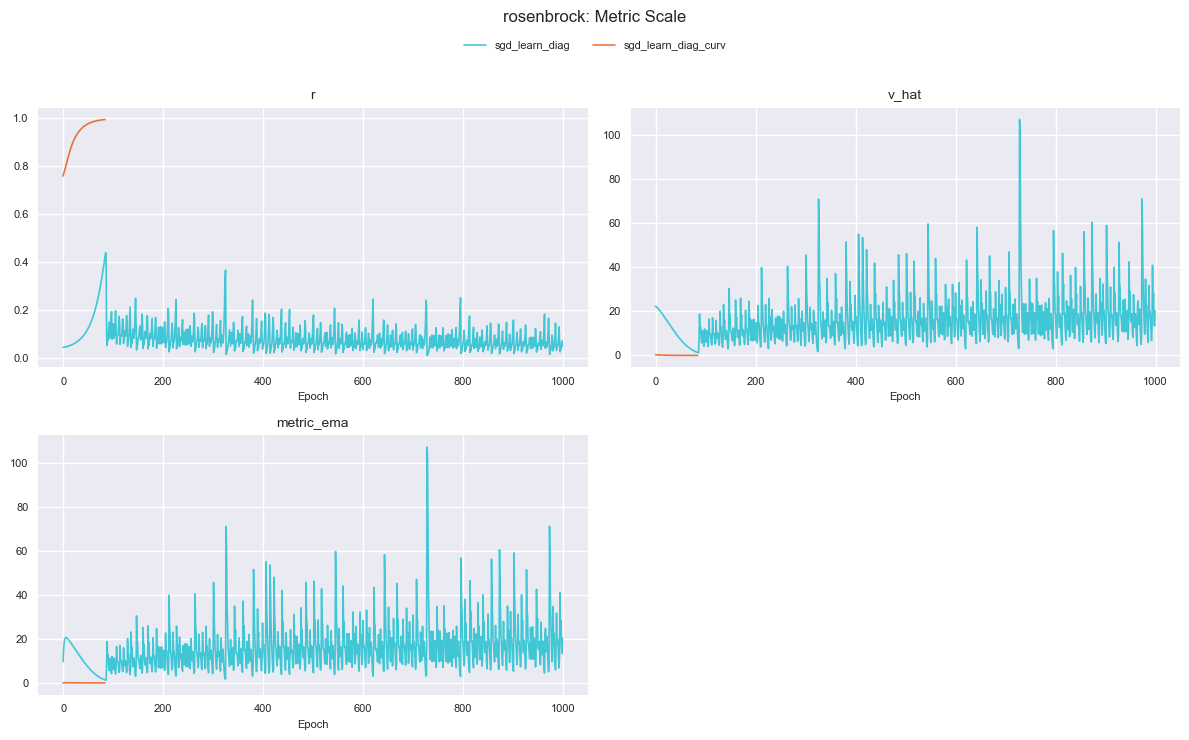

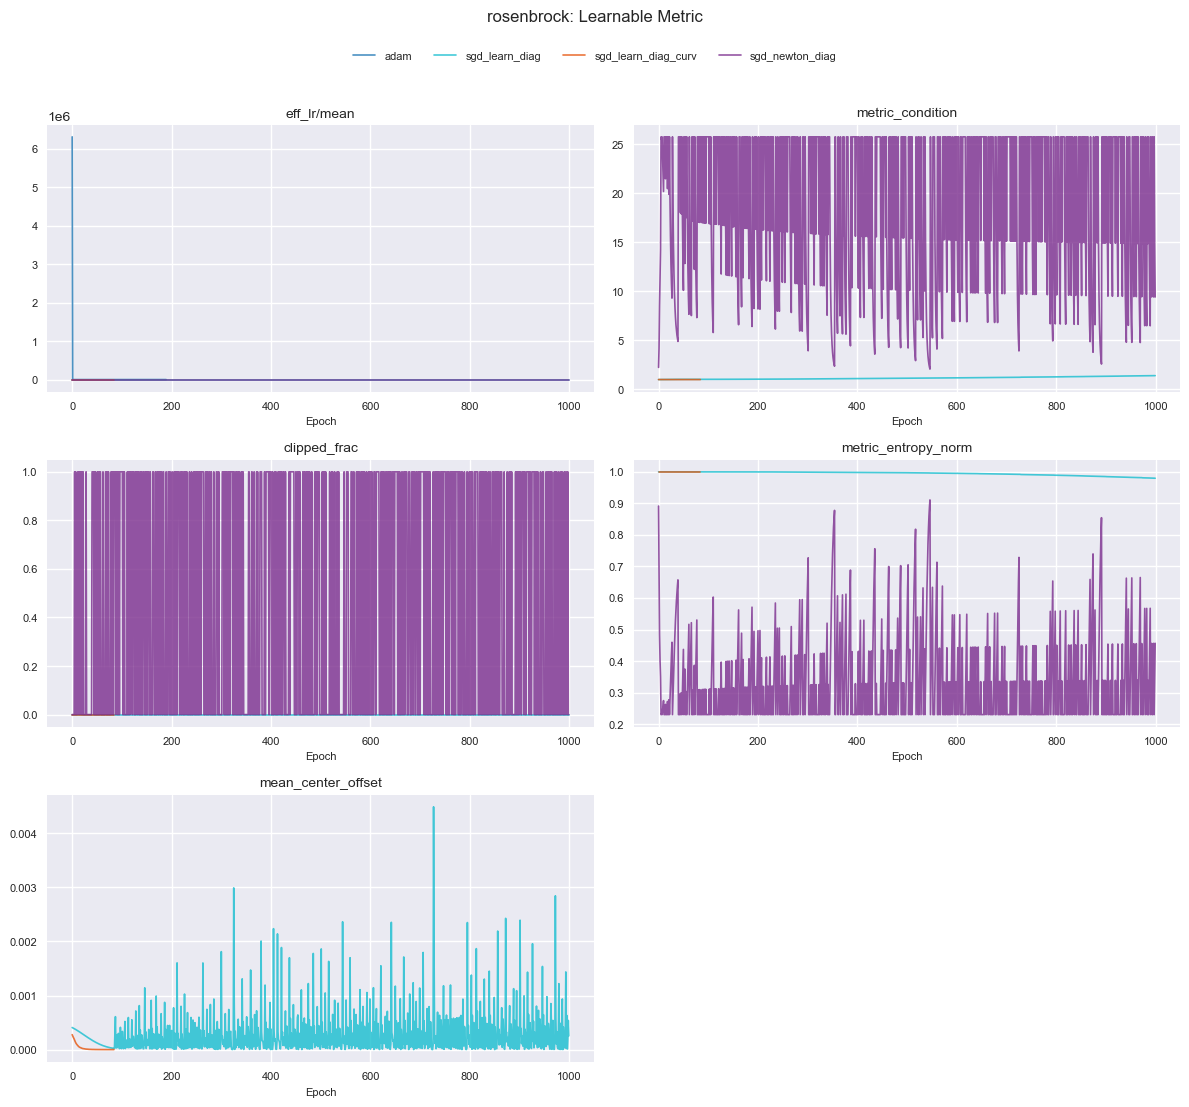

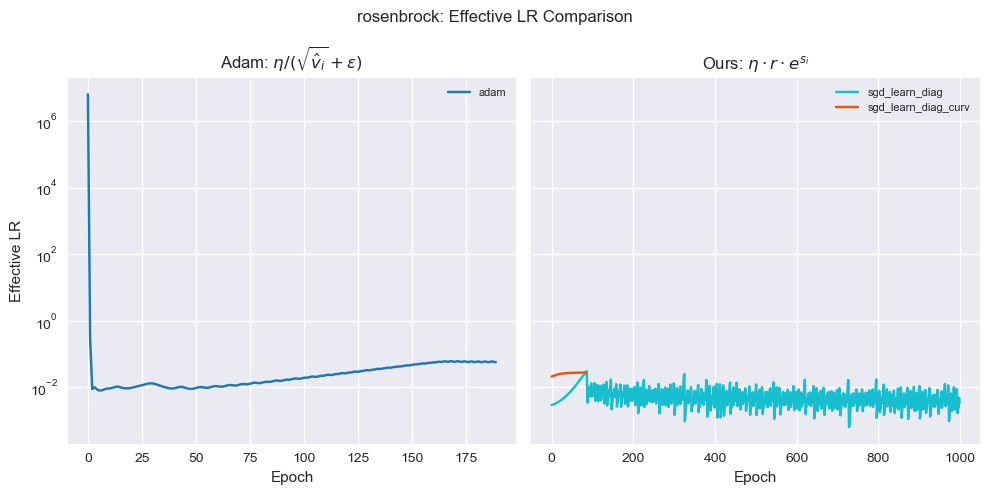

Processing adam...
Processing sgd...
Processing sgd_learn_diag_curv...
Processing sgd_newton_diag...


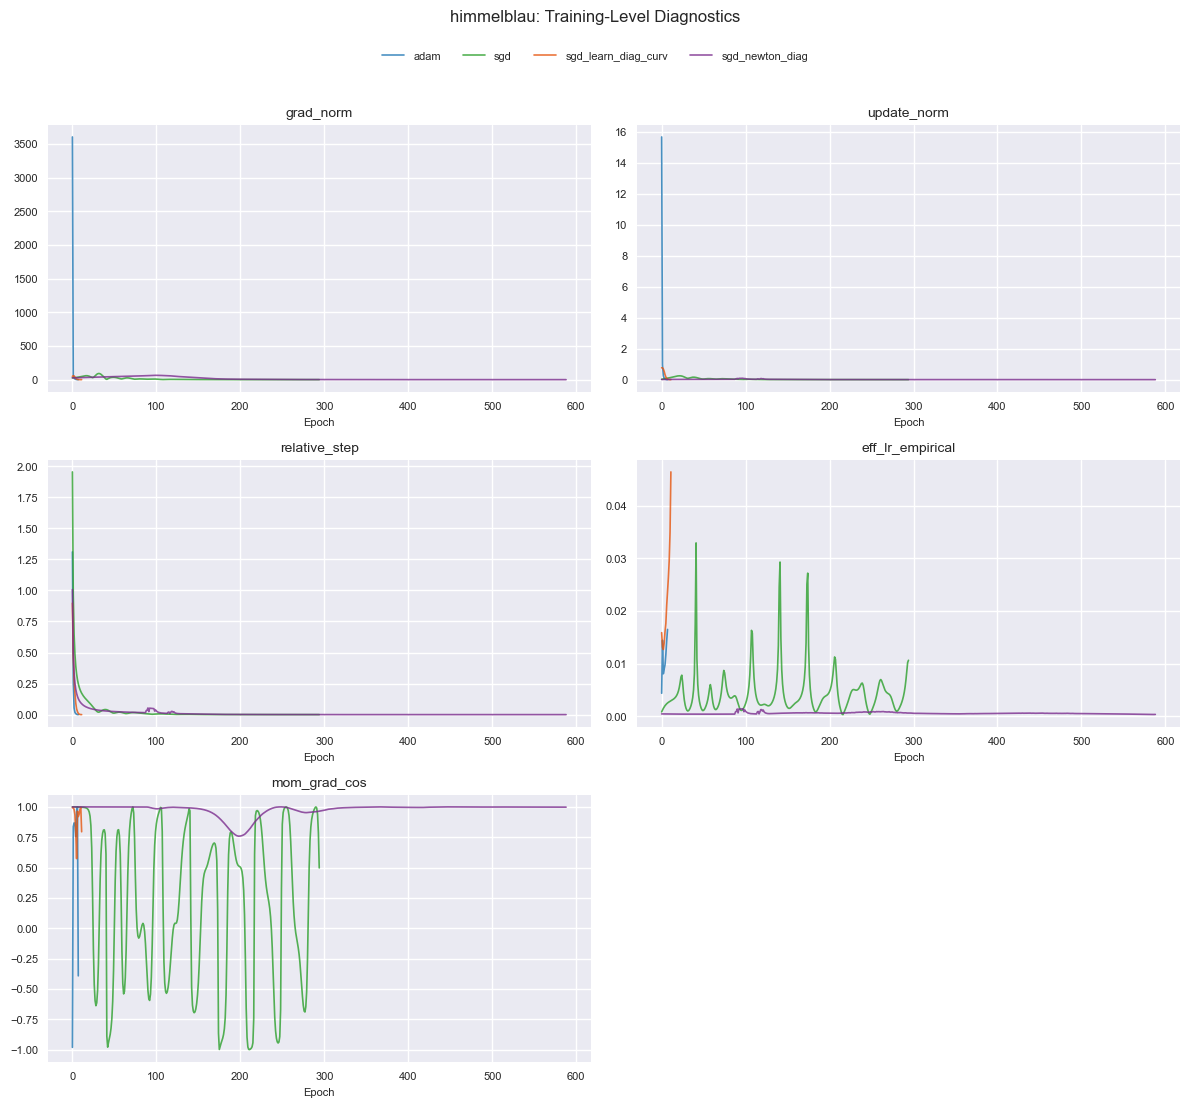

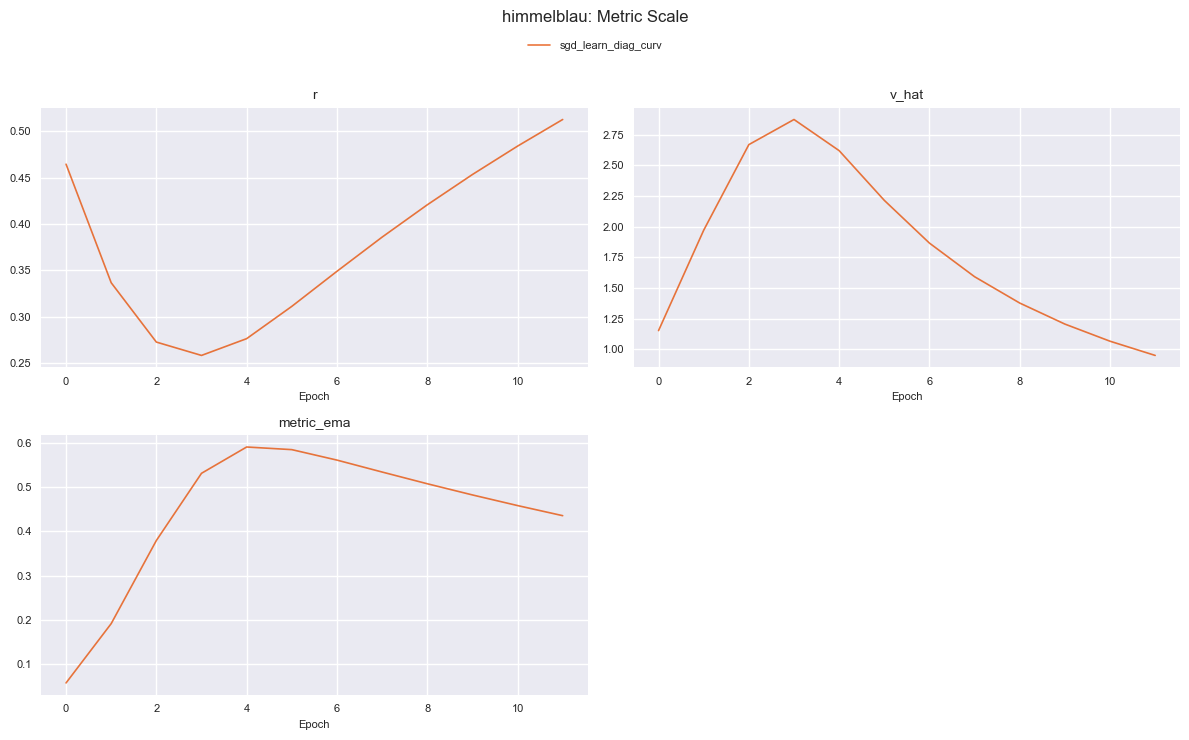

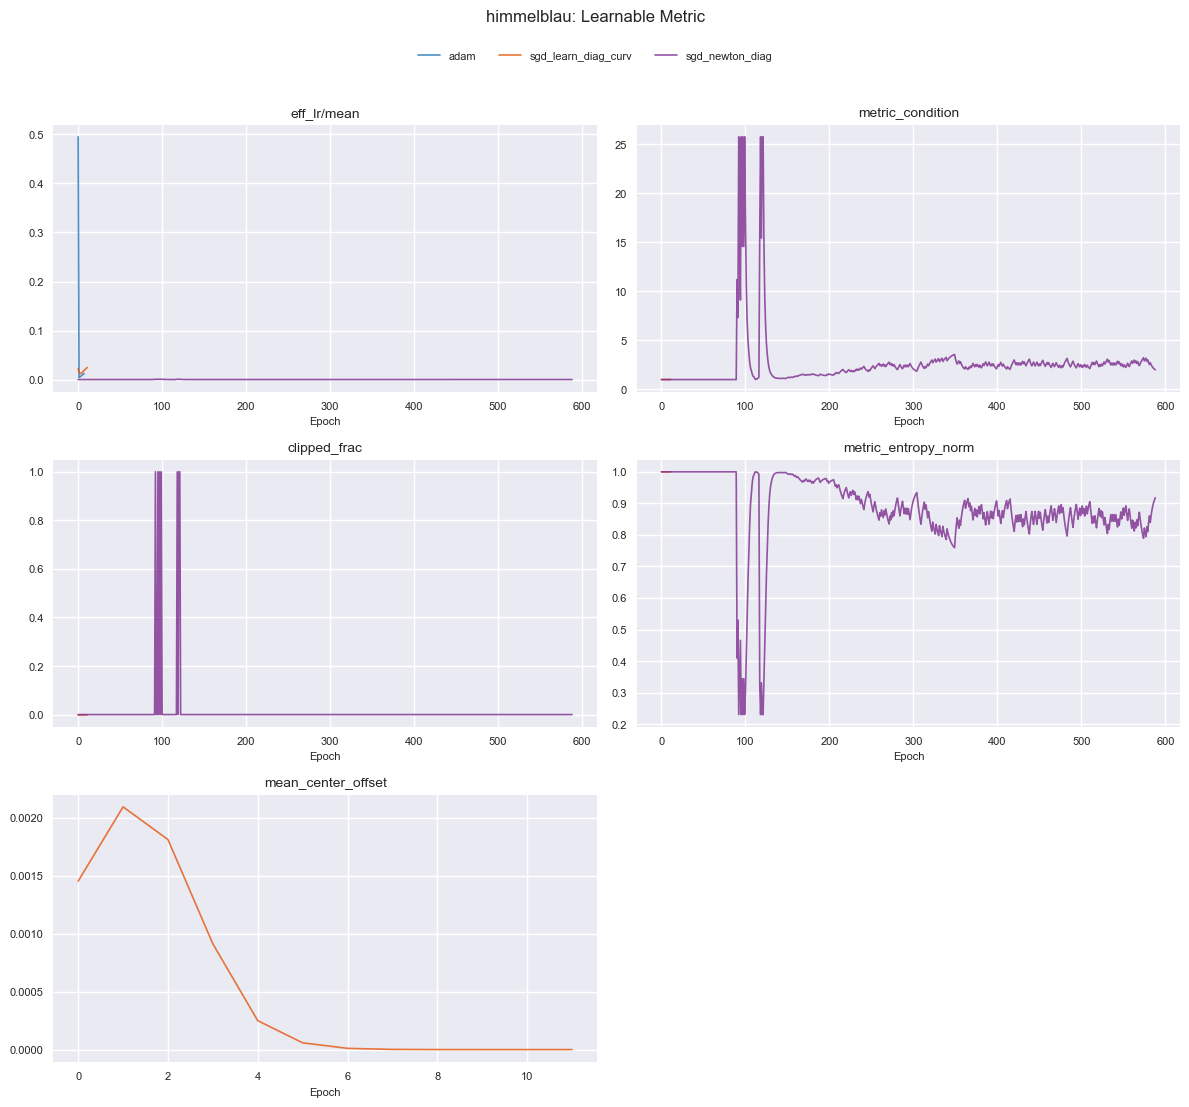

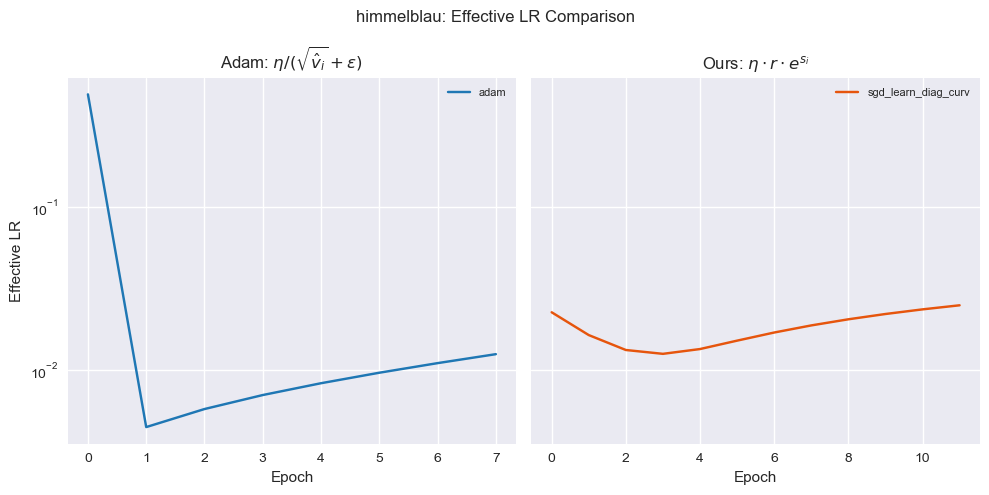

Processing adam...
Processing sgd...
Processing sgd_learn_diag_curv...
Processing sgd_newton_diag...


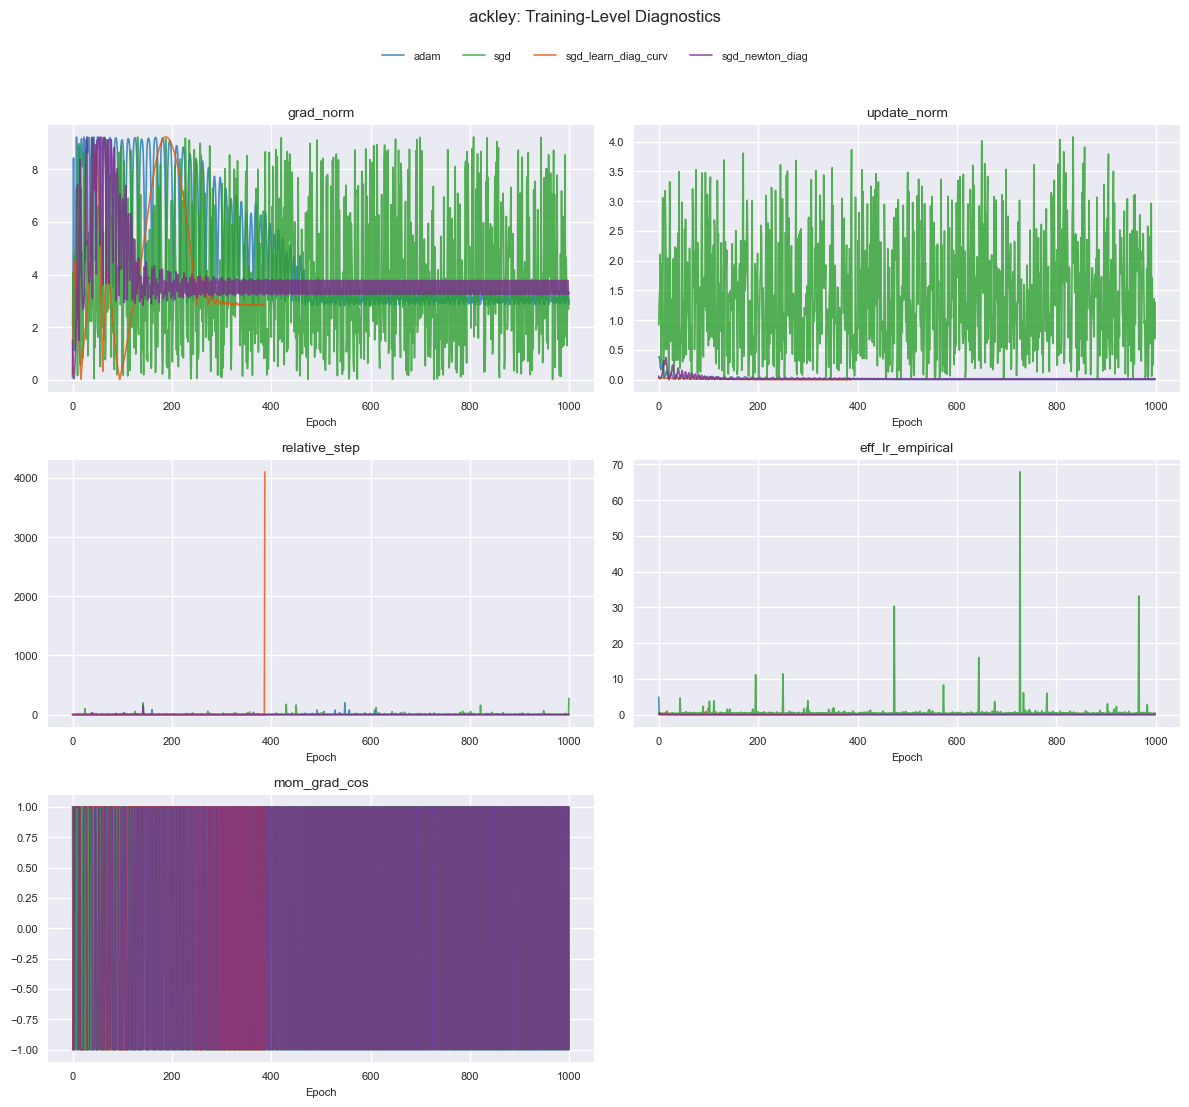

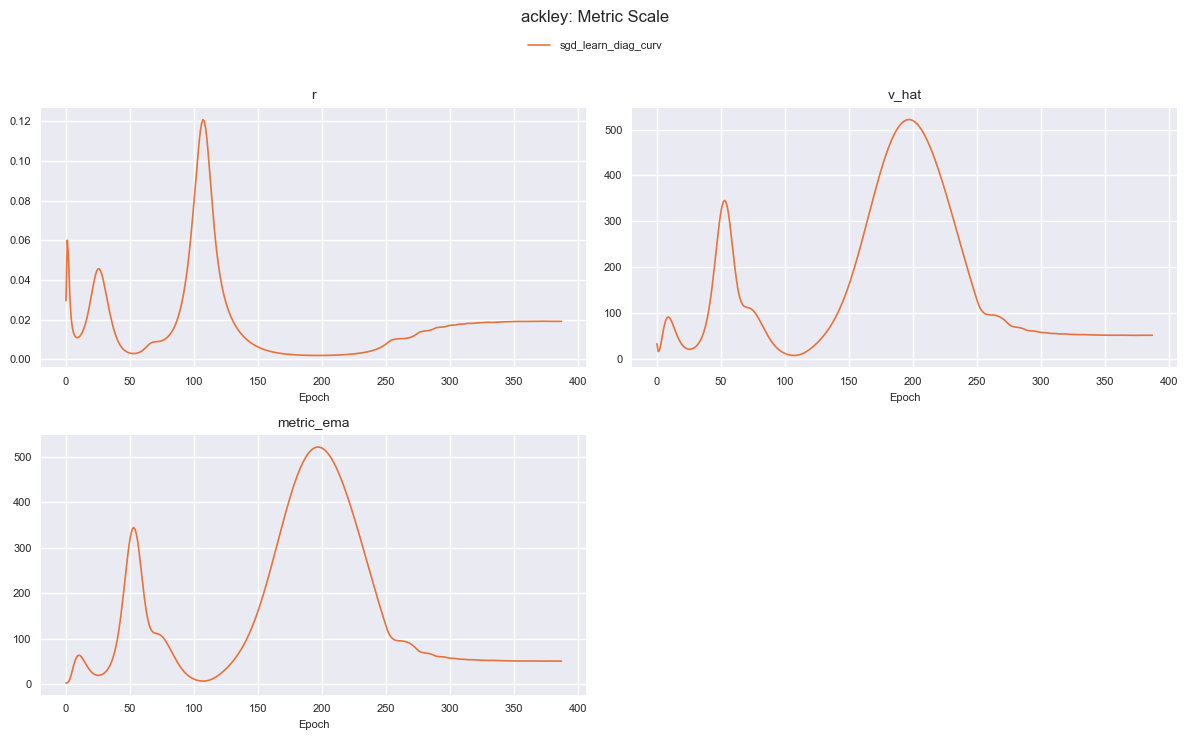

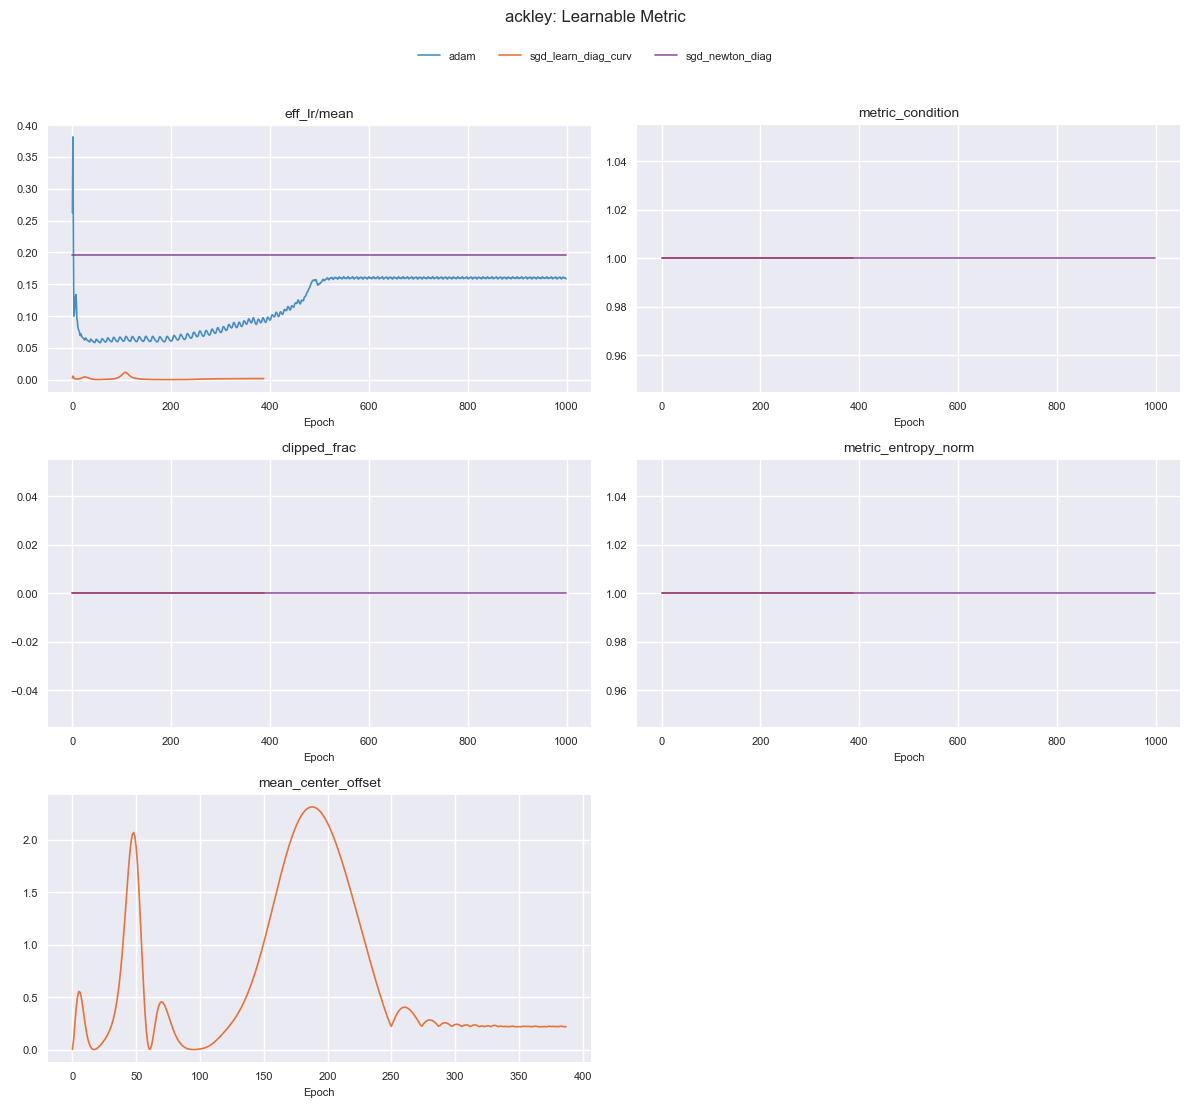

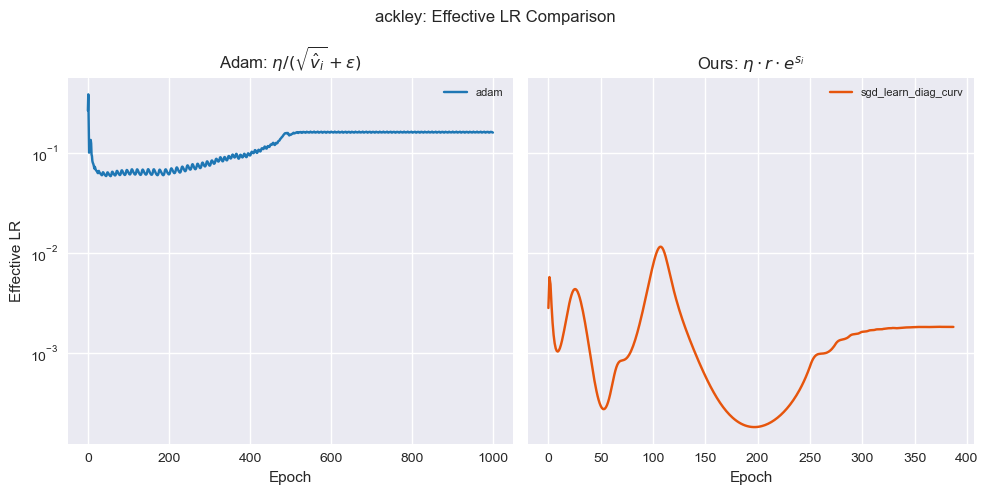

Processing adam...
Processing sgd...
Processing sgd_learn_diag_curv...
Processing sgd_newton_diag...


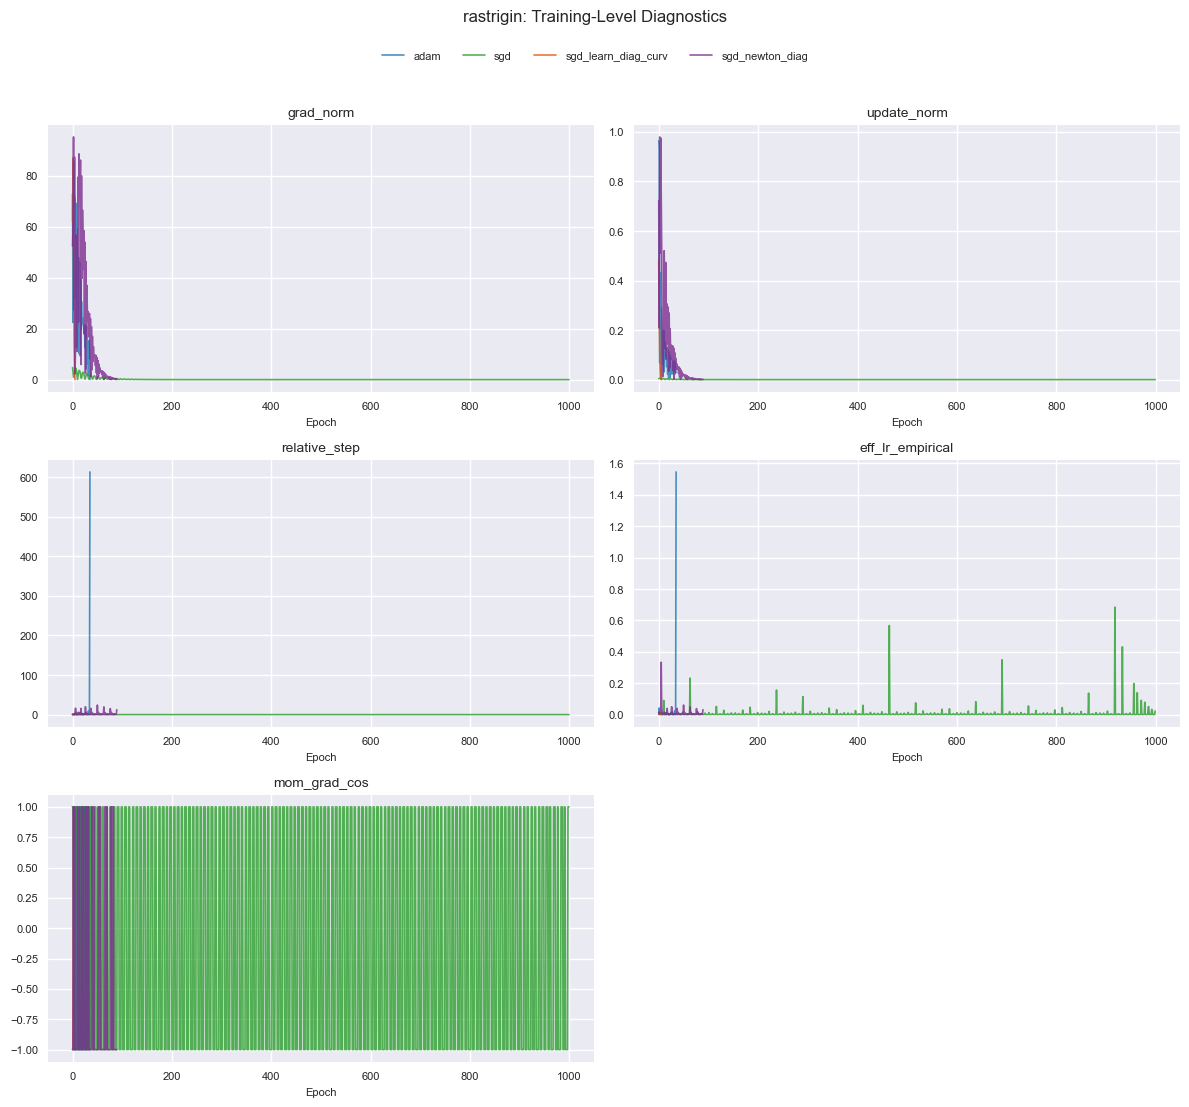

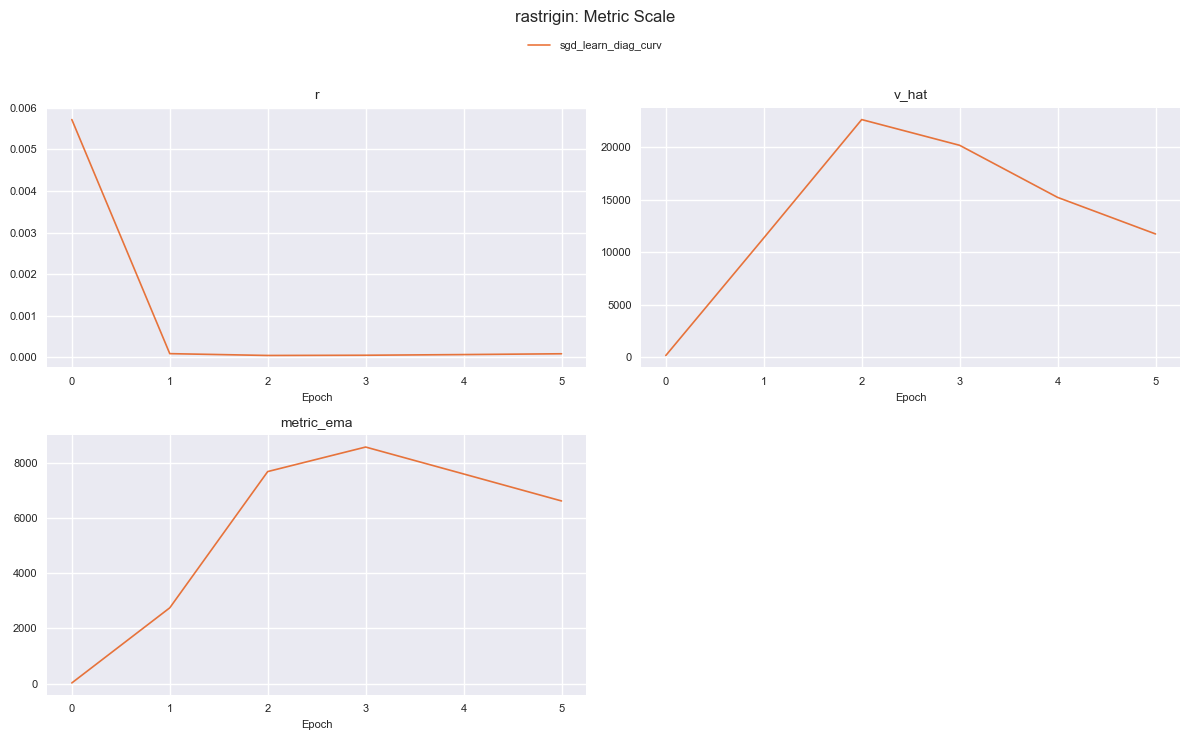

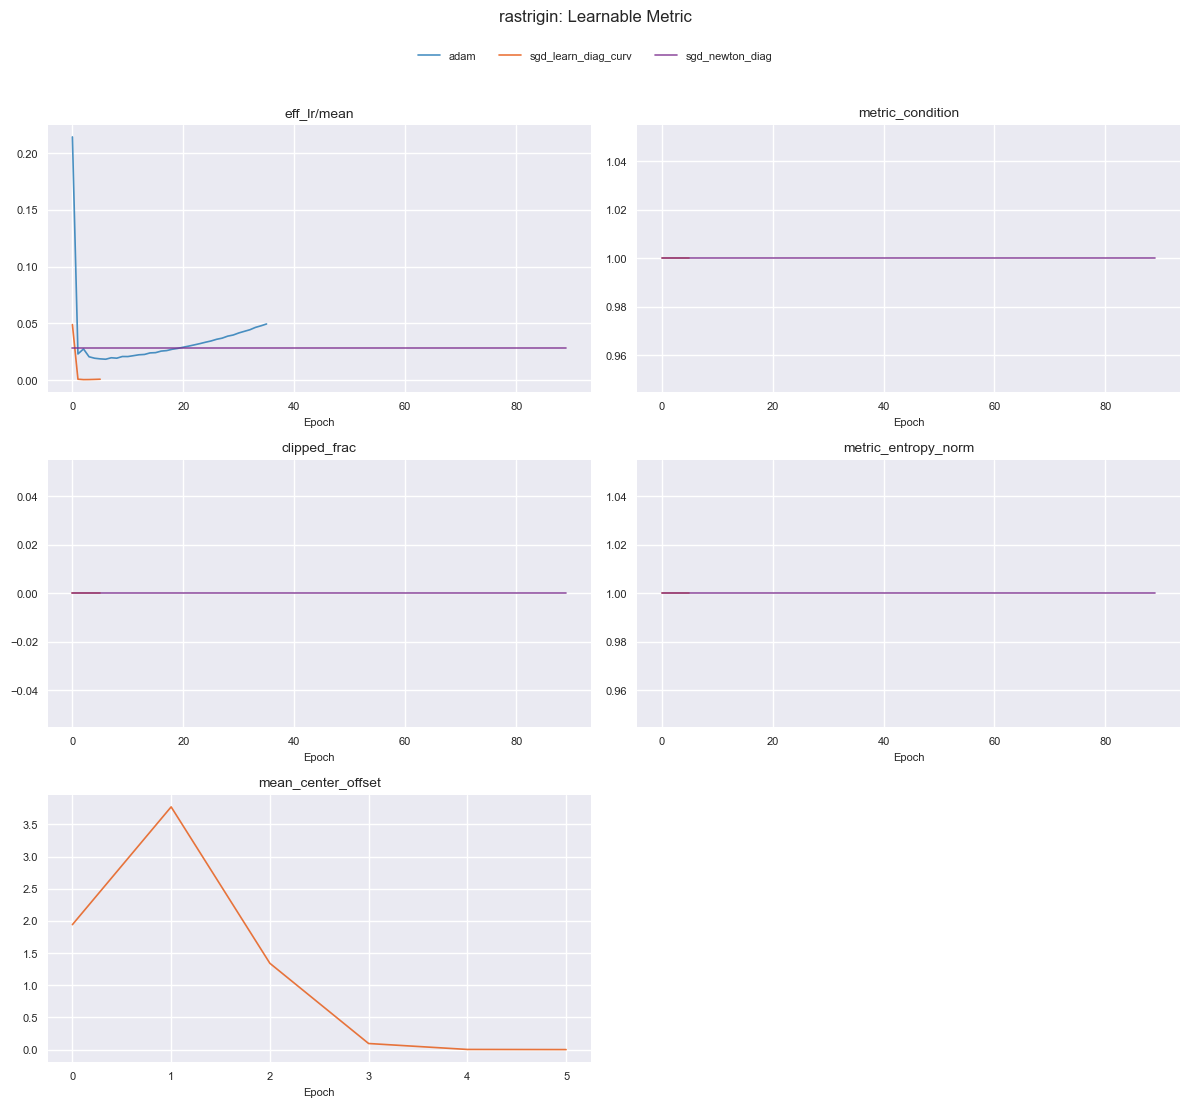

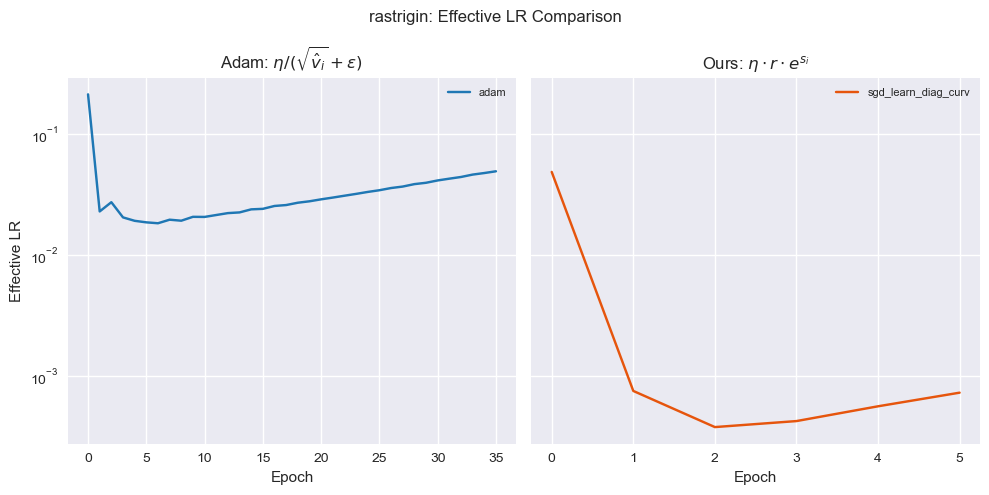

Processing adam...
Processing sgd...
Processing sgd_learn_diag_curv...
Processing sgd_newton_diag...


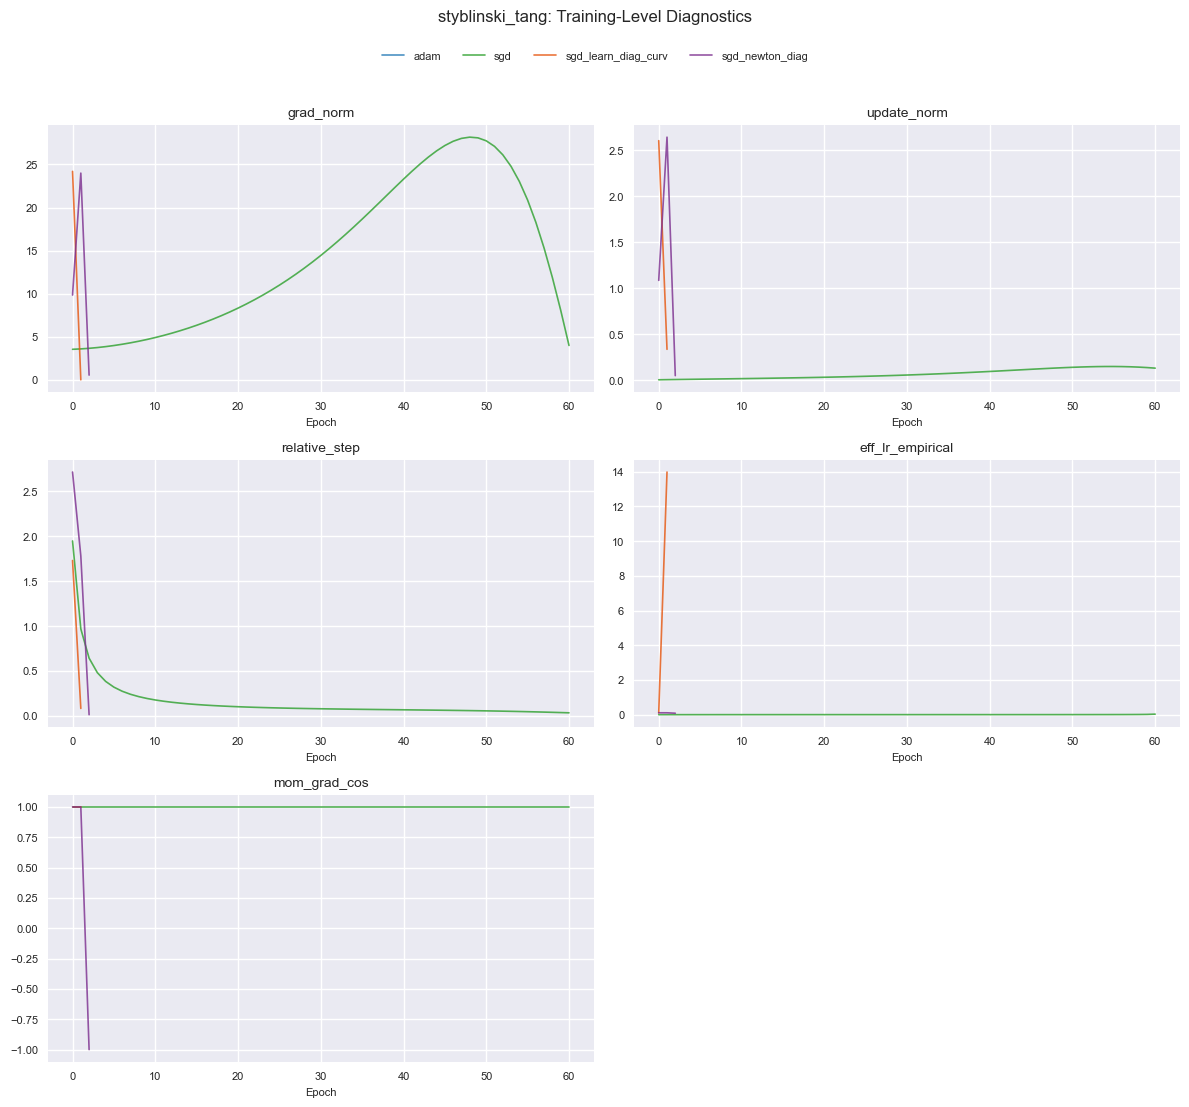

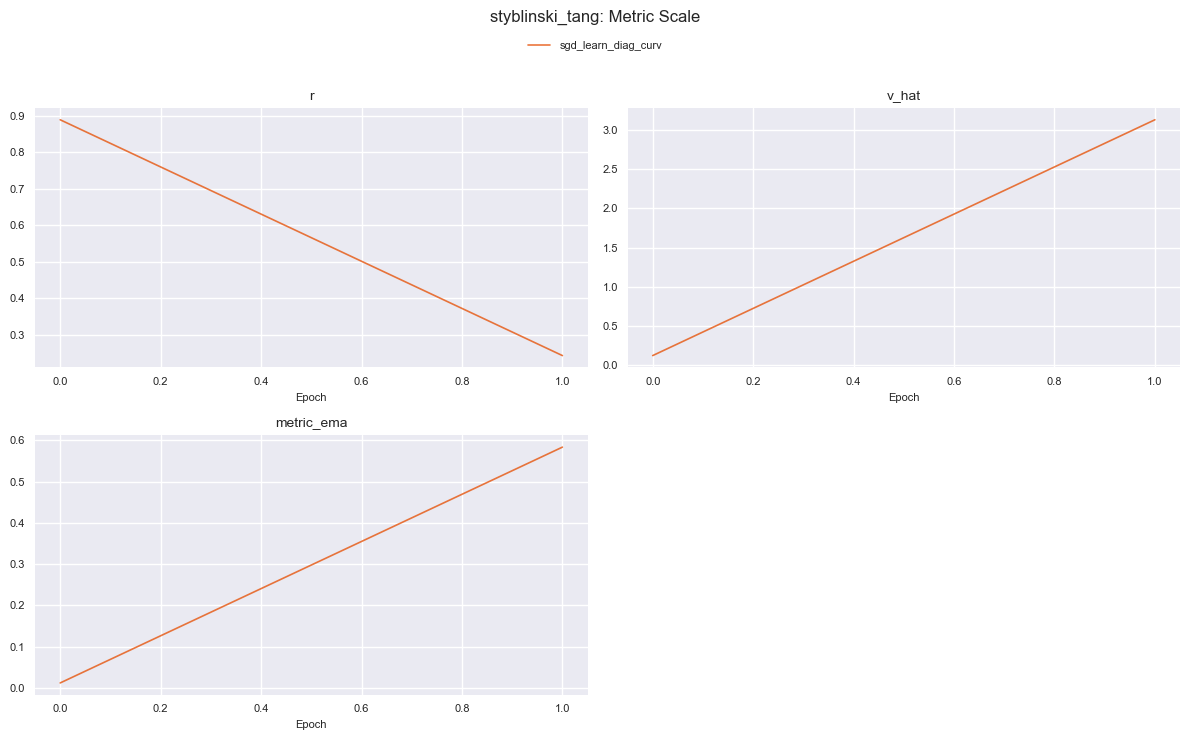

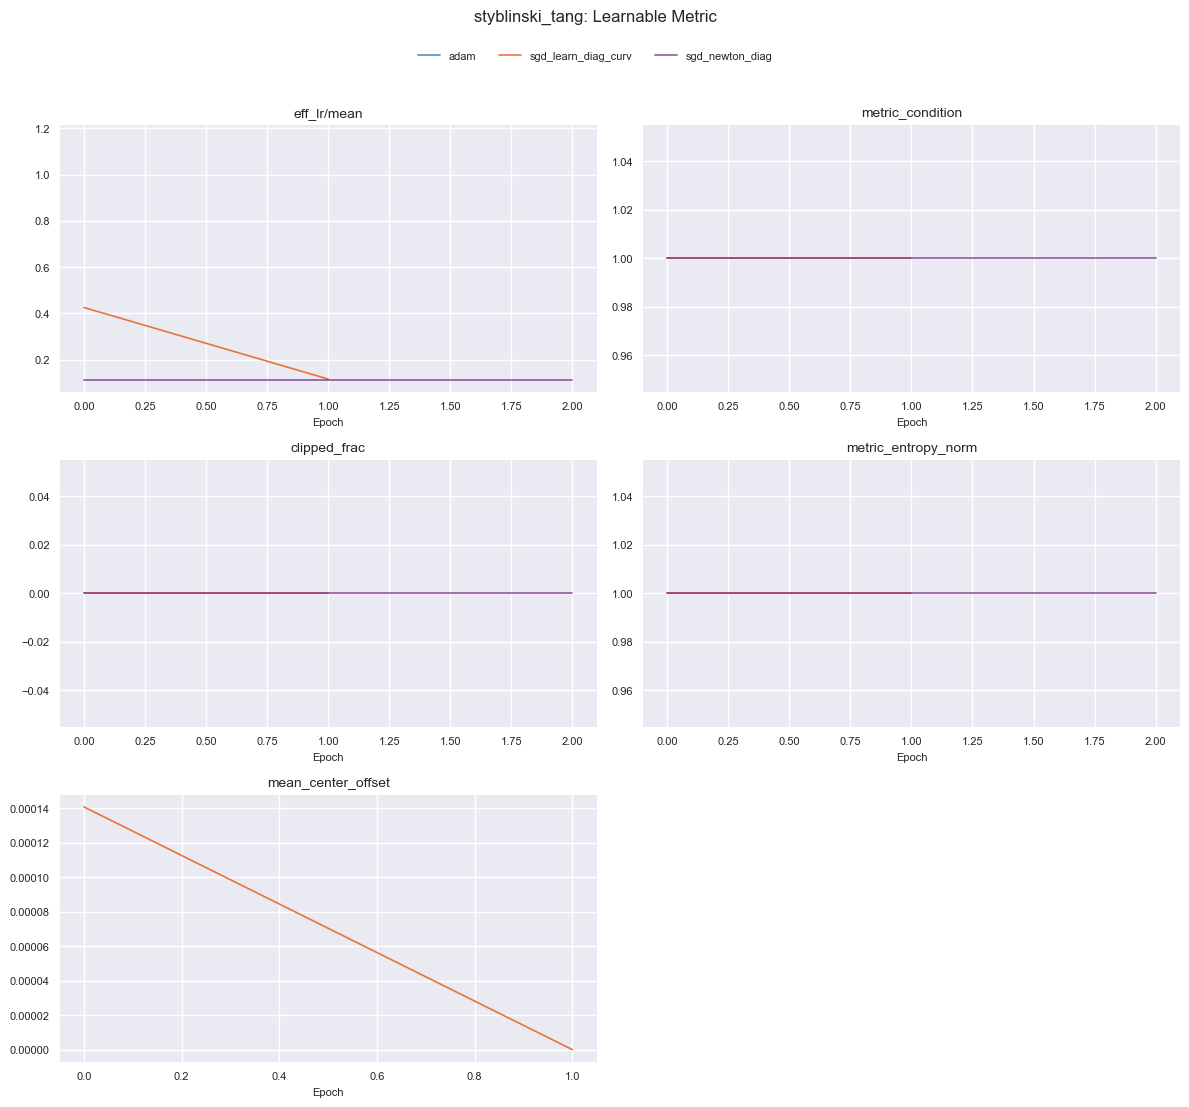

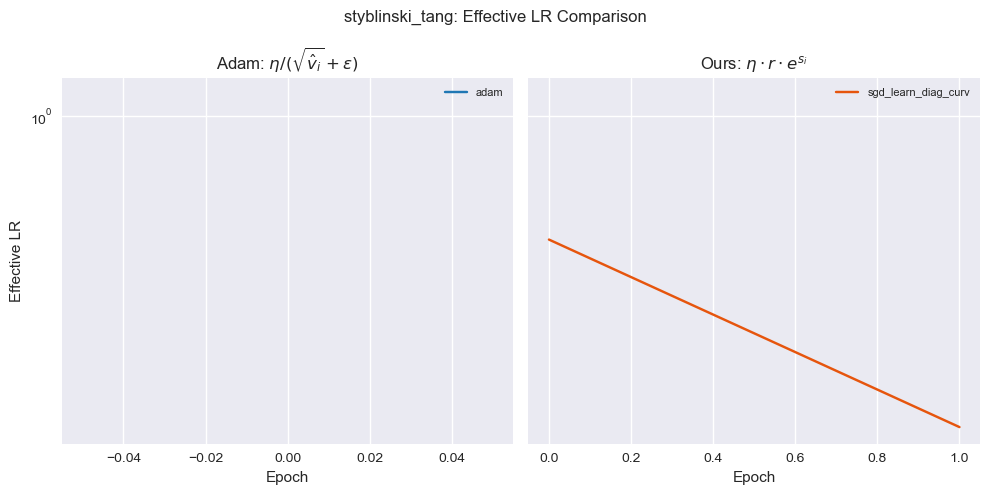

In [17]:
diag_keys = (
    DIAG_KEYS_METRIC_SCALE + DIAG_KEYS_LEARNABLE +
    DIAG_KEYS_CURVATURE + DIAG_KEYS_TRAINING + DIAG_KEYS_OFFDIAG
)

for func_name in FUNCTIONS:
    best_runs = all_best_runs.get(func_name, {})
    if not best_runs:
        continue
    diag_data = extract_history(BACKEND, best_runs, diag_keys)

    plot_diagnostic_curves(diag_data, DIAG_KEYS_TRAINING,
        title=f"{func_name}: Training-Level Diagnostics")
    plt.show()

    plot_diagnostic_curves(diag_data, DIAG_KEYS_METRIC_SCALE,
        title=f"{func_name}: Metric Scale")
    plt.show()

    plot_diagnostic_curves(diag_data, DIAG_KEYS_LEARNABLE,
        title=f"{func_name}: Learnable Metric")
    plt.show()

    plot_effective_lr_comparison(diag_data,
        title=f"{func_name}: Effective LR Comparison")
    plt.show()
